# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 49    |  |
| :-------------|:-------------|
| Nina Gumbs| 6552544 |
| Hugo van Krevel| 658993 |
| Teun van Zeeland| 6479510|

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Teun','Hugo'] #En Nina

## Opdracht 1: Planning.

| Planning Groep: 49     |Tijdstip / Tijdspanne  |
|---|---|
| Testen meetopstelling | 12:30 |
| Iteraties | 15:30 |
| Algoritme klaar | 16:00 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| 10:45 |
| Pauze 1| 12:30 |
| Pauze 2| 15:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [49]
<img src="kalibratie.jpeg" width="400"  style="transform:rotate(180deg);">

0.03402902047516232 0.37401216726830466


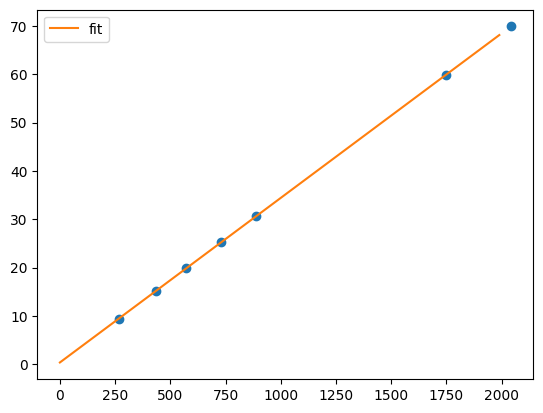

In [3]:
# verwerk hier jullie kalibratiemetingen
waarde_arduino = np.array([266,435,573,730,888,2042,1748])
afstand = np.array([10,15,20,25,30,70,60])

def model(waarde_arduino,a,b):
    return a*waarde_arduino+b

popt, pcov = curve_fit(model,waarde_arduino,afstand)
a = popt[0]
b = popt[1]

afstand = model(waarde_arduino,a,b)

plt.plot(waarde_arduino,afstand,'o')
print(a,b)

x = np.arange(0,2000,10)
y = a * x + b
plt.plot(x,y,label = 'fit')
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  40.50
1   0  30   0  20  40.36
2  40   0  30   0  41.70
3  30   0  20   0  41.50


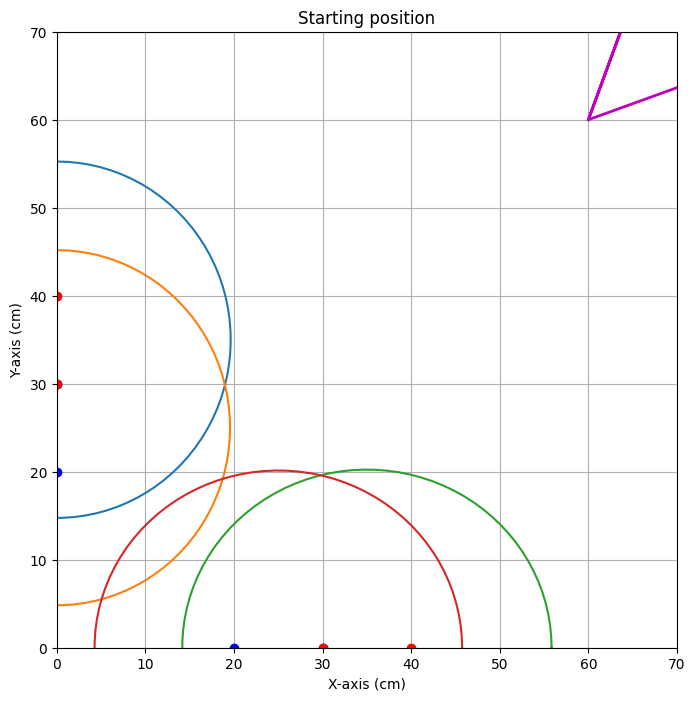


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.940


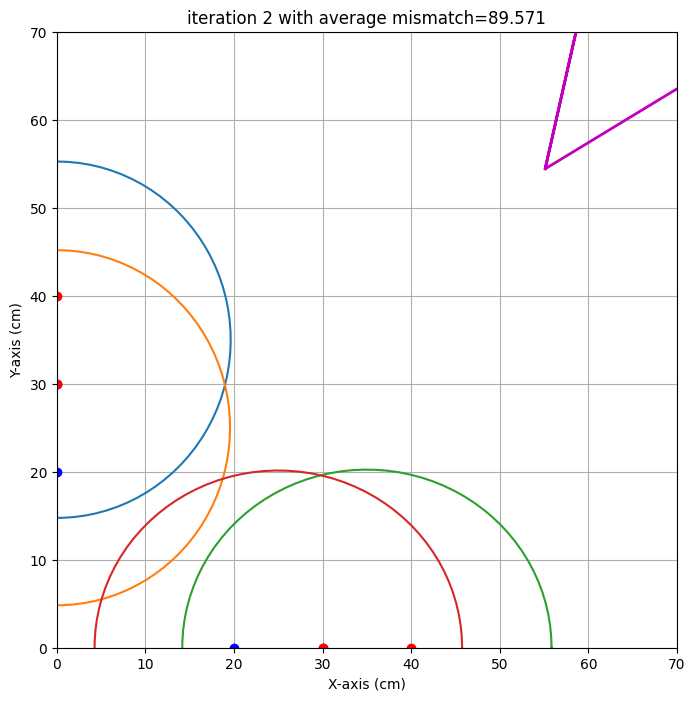

end iteration 2 with average mismatch=89.571


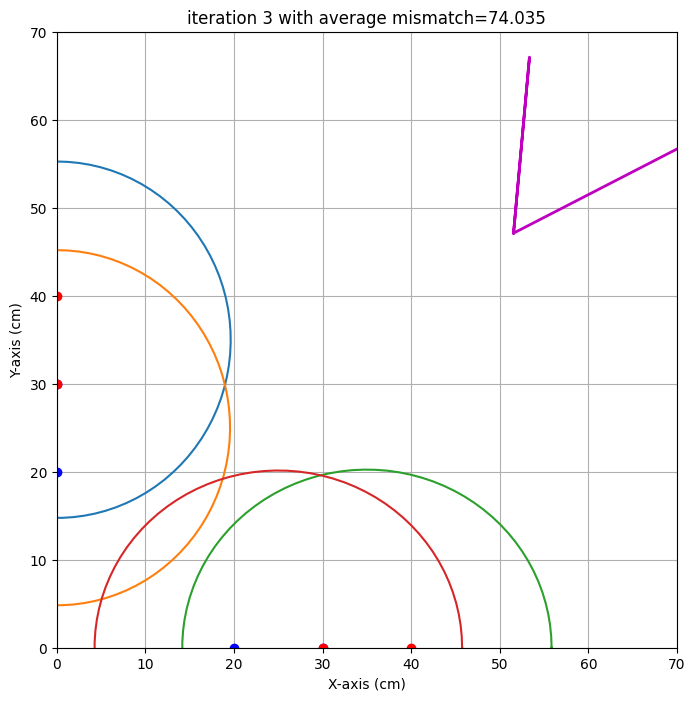

end iteration 3 with average mismatch=74.035


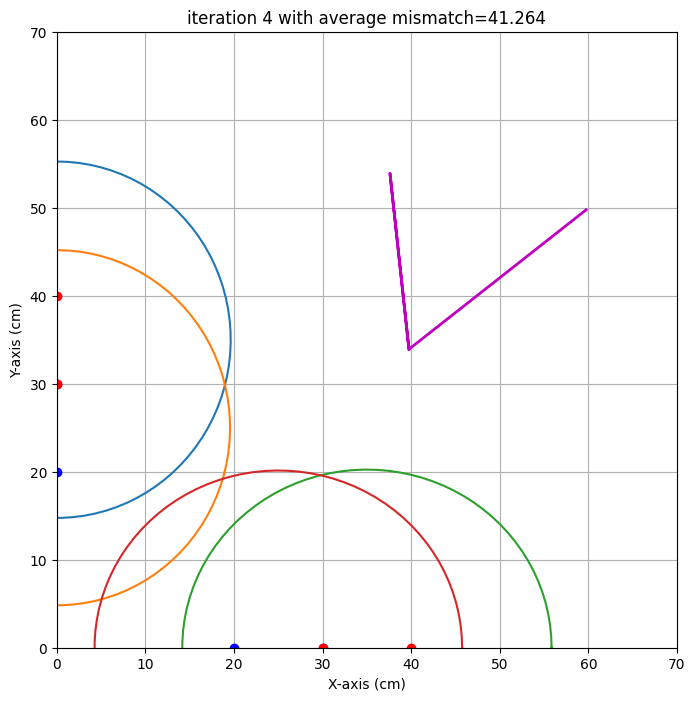

end iteration 4 with average mismatch=41.264


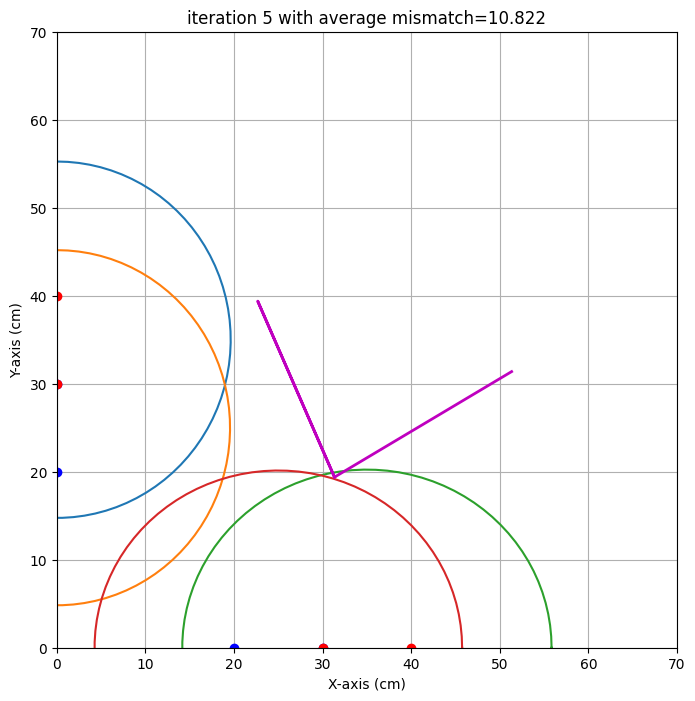

end iteration 5 with average mismatch=10.822


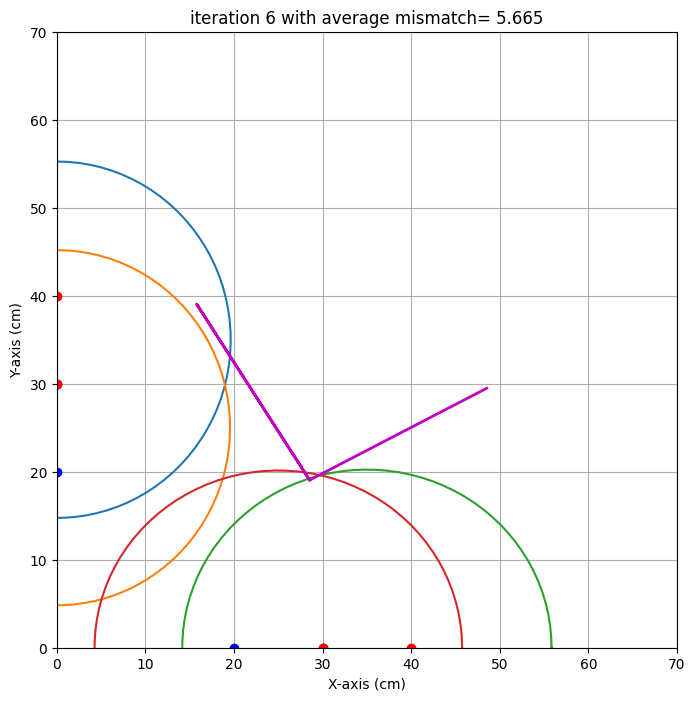

end iteration 6 with average mismatch= 5.665


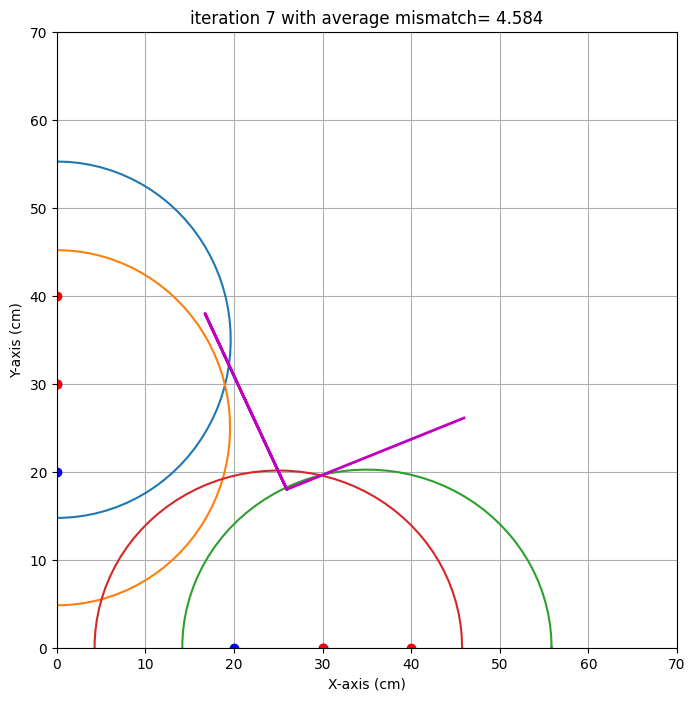

end iteration 7 with average mismatch= 4.584


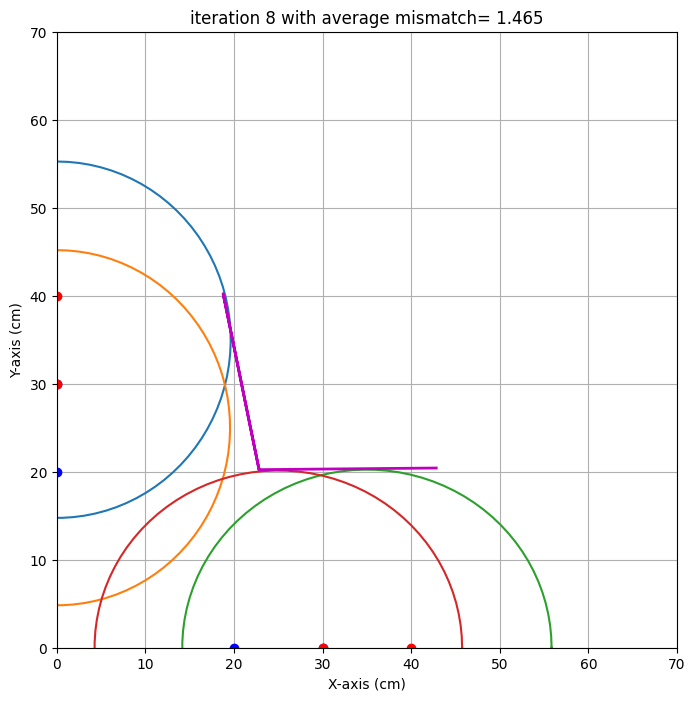

end iteration 8 with average mismatch= 1.465


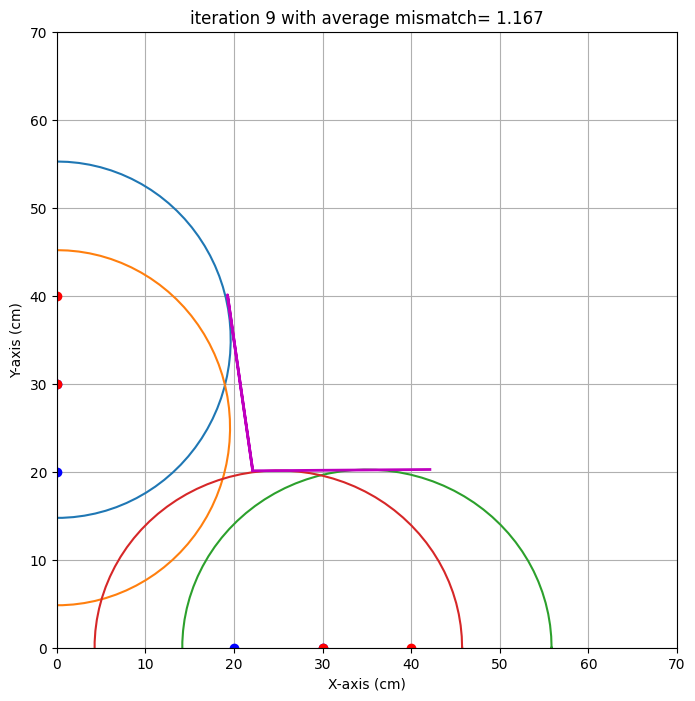

end iteration 9 with average mismatch= 1.167


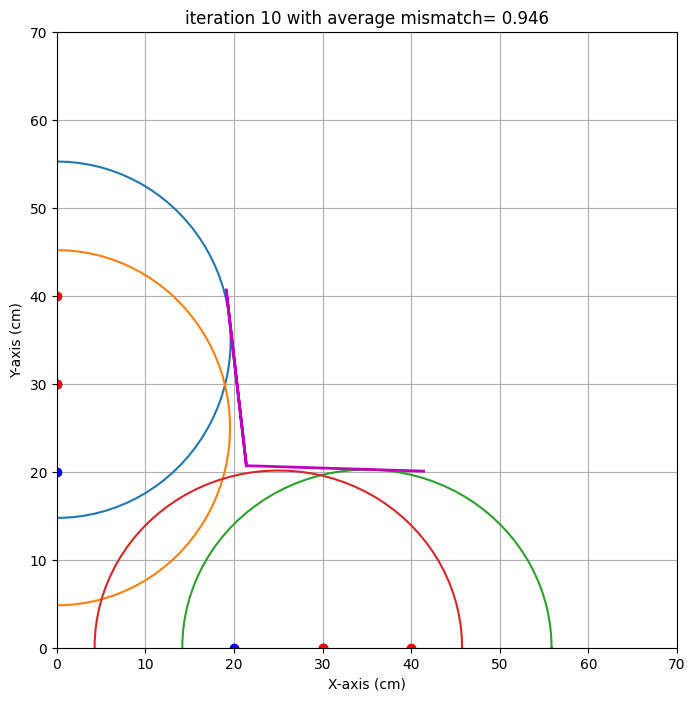

end iteration 10 with average mismatch= 0.946


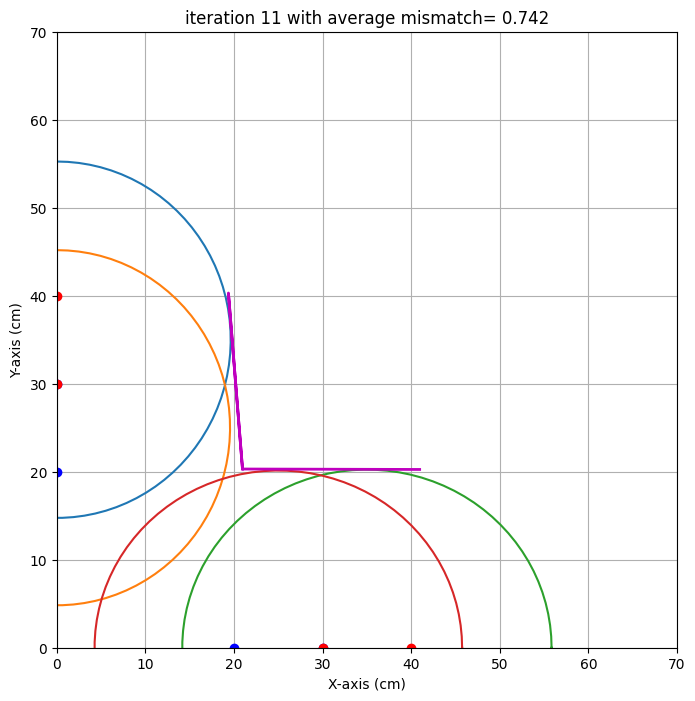

end iteration 11 with average mismatch= 0.742
end iteration 12 with average mismatch= 0.698


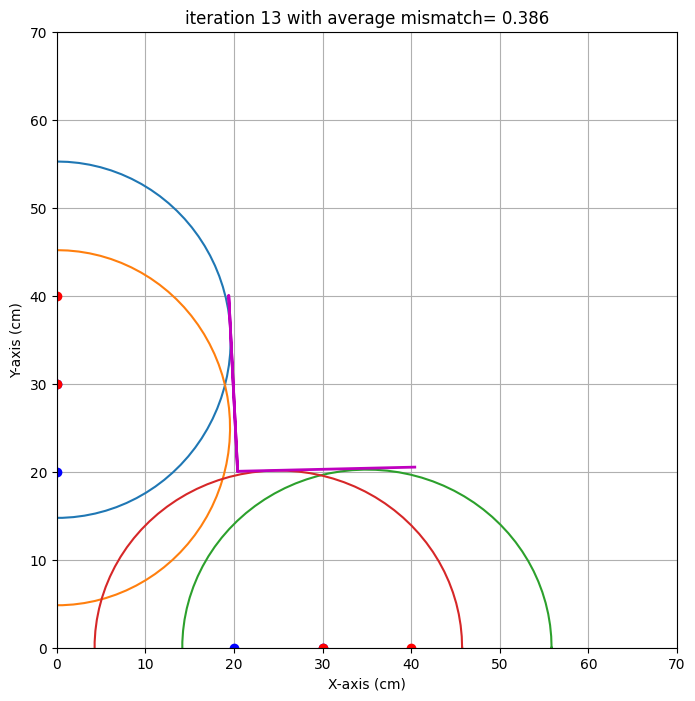

end iteration 13 with average mismatch= 0.386
end iteration 14 with average mismatch= 0.380
end iteration 15 with average mismatch= 0.378
end iteration 16 with average mismatch= 0.378
end iteration 17 with average mismatch= 0.378


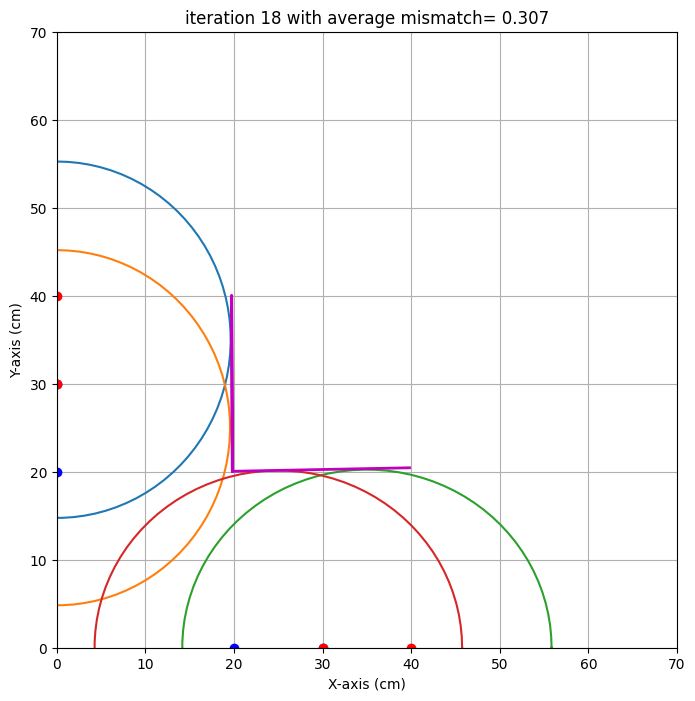

end iteration 18 with average mismatch= 0.307
end iteration 19 with average mismatch= 0.282
end iteration 20 with average mismatch= 0.275
end iteration 21 with average mismatch= 0.272
end iteration 22 with average mismatch= 0.272
end iteration 23 with average mismatch= 0.272
end iteration 24 with average mismatch= 0.272
end iteration 25 with average mismatch= 0.272
end iteration 26 with average mismatch= 0.272
end iteration 27 with average mismatch= 0.272
end iteration 28 with average mismatch= 0.272
end iteration 29 with average mismatch= 0.272
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.272
###############################################################################
end of iteration  30
Best alpha=   1.13 with uncertainty=   1.62
Best beta =  -0.23 with uncertainty=   1.30
Best x0   =  19.79 with uncertainty=   0.45
Best y0   =  20.03 with uncertainty=   0.45
################

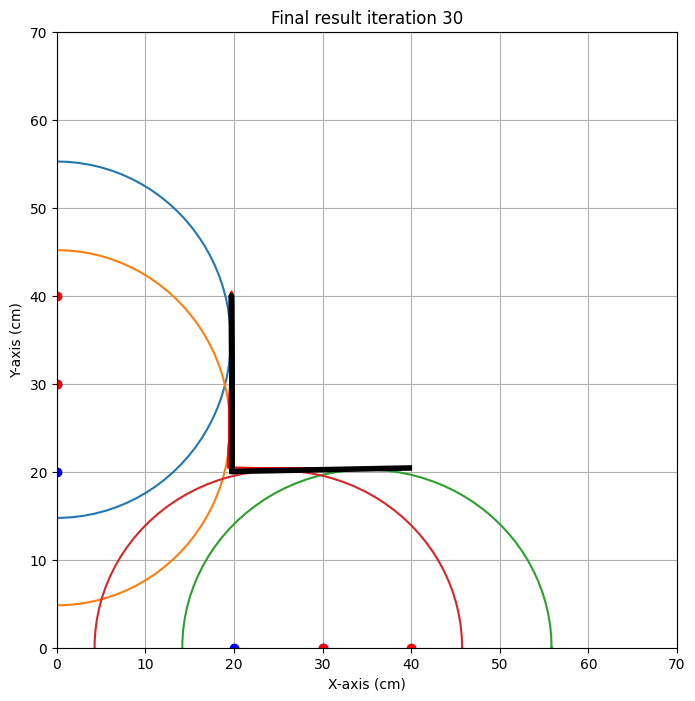

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.36],
    #[0,10,0,20,192.60],
    [40,0,30,0,41.70],
    [30,0,20,0,41.50],
    #[10,0,20,0,],
    #[10,0,0,10,22.87]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.8 cm met een standaardafwijking van 0.4 cm 
y0: 20.0 cm met een standaardafwijking van 0.5 cm 
alpha: 1.1 graden met een standaardafwijking van 1.6 graad 
beta: -0.2 graden met een standaardafwijking van 1.3 graad 



## Opdracht 5: Iteratie 0

Tussen 40 en 110 telt als logische meting

#### algoritme [Teun]
<img src="schets1.jpeg" width="350">

#### algoritme [Hugo]
<img src="schets2.jpeg" width="350">

#### algoritme [Nina]
<img src="schets3.jpeg" width="350">

## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': 38,
           'alpha': 1,
           'beta' : 1
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Teun' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,79.05],
    [50,0,60,0,83.60],
    [0,40,0,50,61.10],
    [0,50,0,60,59.60]
    ]),
       'Hugo' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   [40,0,30,0,82.80],
   [30,0,20,0,98.50],
   #Niet logisch[0,40,0,30,]
   [0,50,0,40,59.35],
   [0,60,0,50,55.0]
    ])
      }

## Opdracht 7: Evaluatie.

Teun
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  50   0  79.05
1  50   0  60   0  83.60
2   0  40   0  50  61.10
3   0  50   0  60  59.60


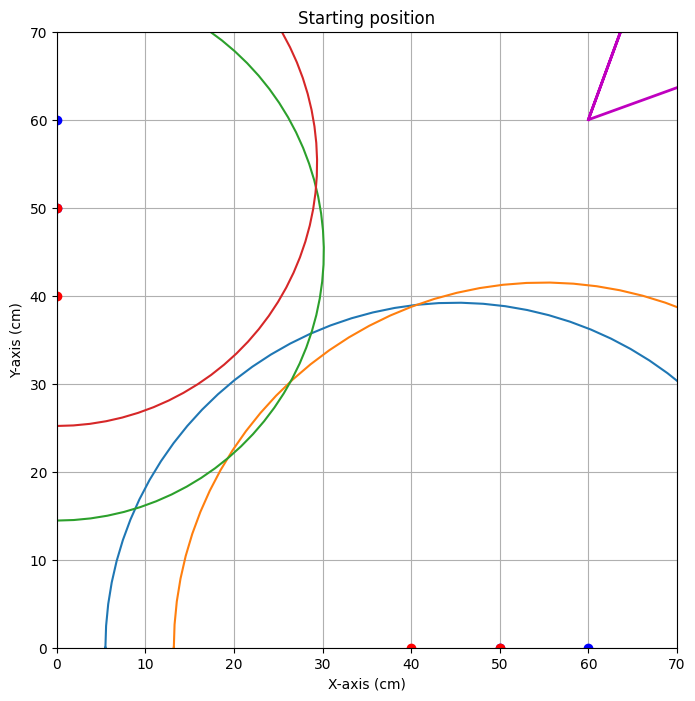


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.735


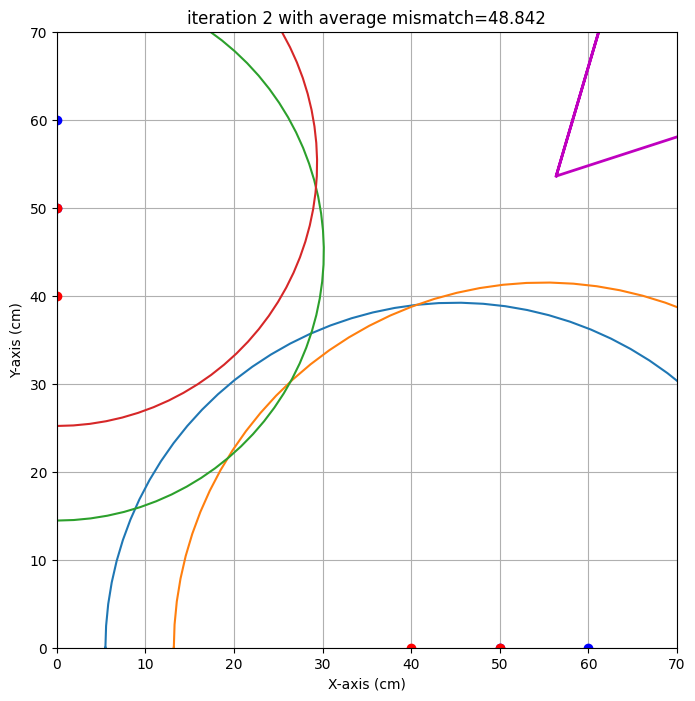

end iteration 2 with average mismatch=48.842


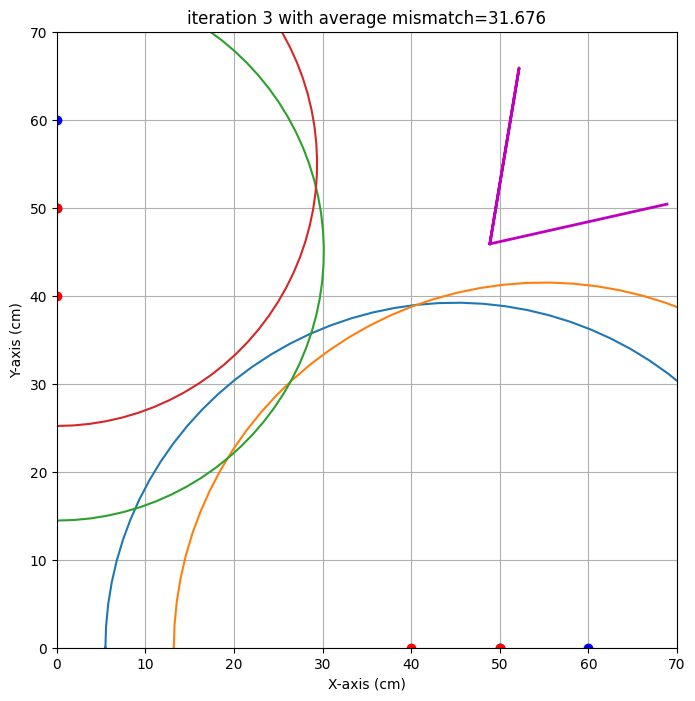

end iteration 3 with average mismatch=31.676


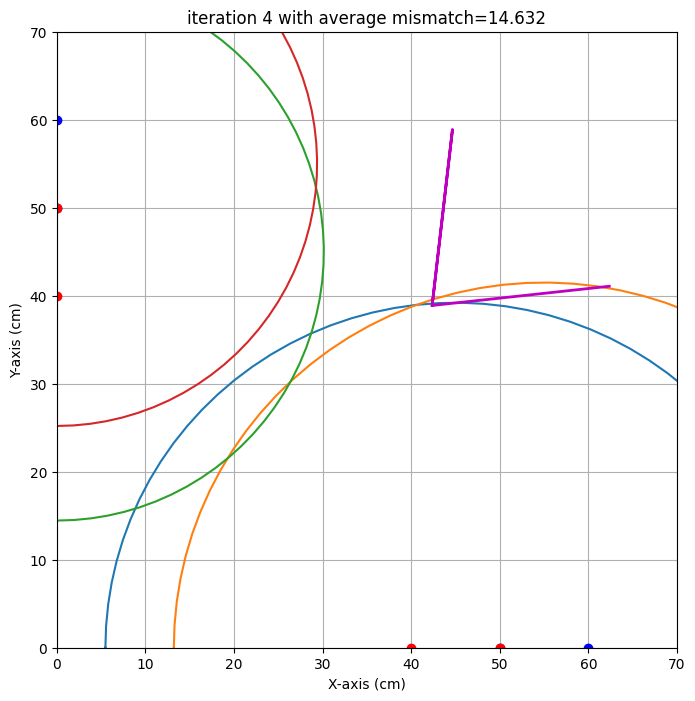

end iteration 4 with average mismatch=14.632


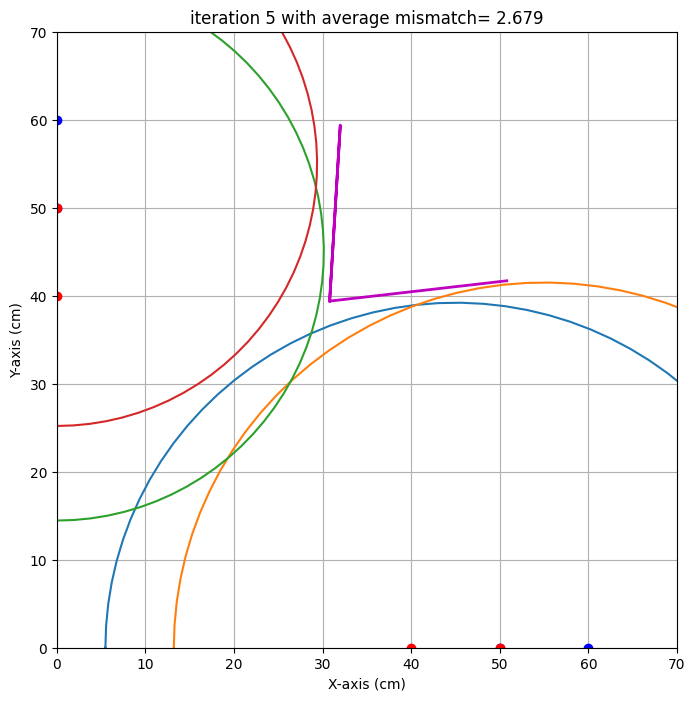

end iteration 5 with average mismatch= 2.679


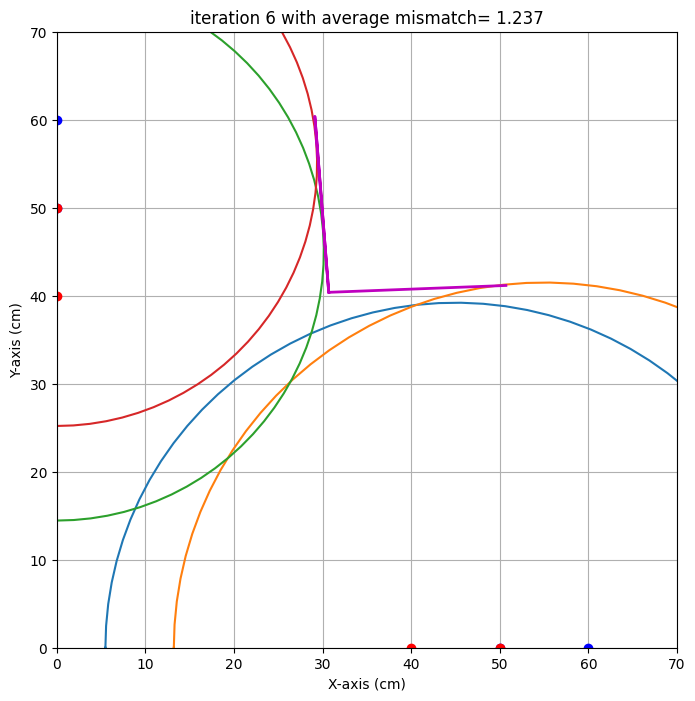

end iteration 6 with average mismatch= 1.237


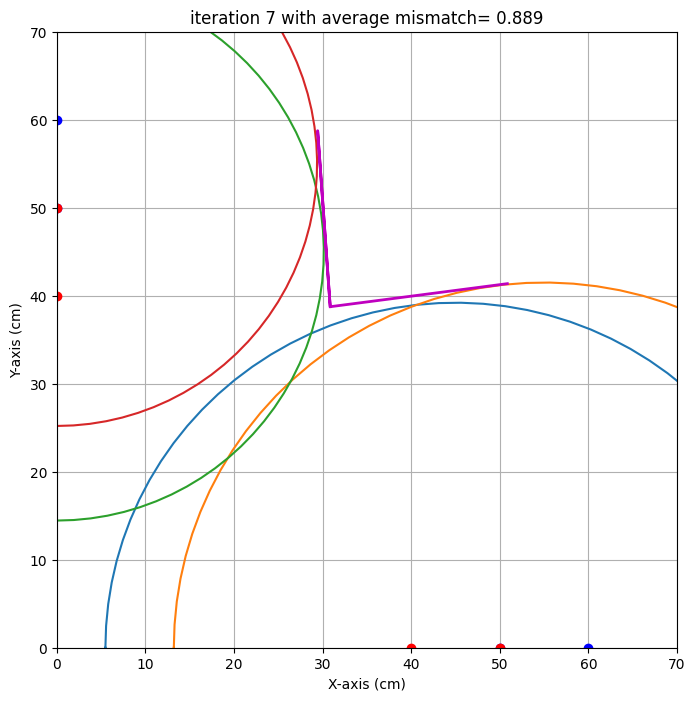

end iteration 7 with average mismatch= 0.889


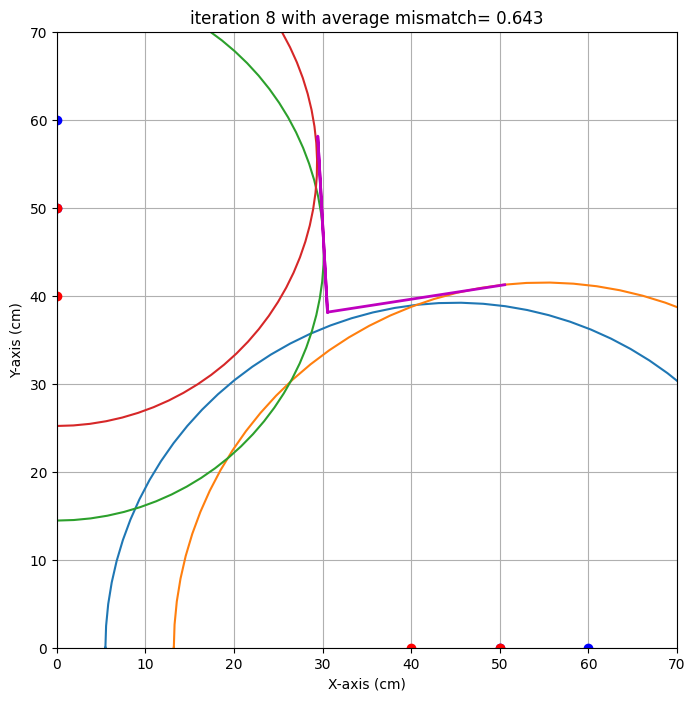

end iteration 8 with average mismatch= 0.643
end iteration 9 with average mismatch= 0.643


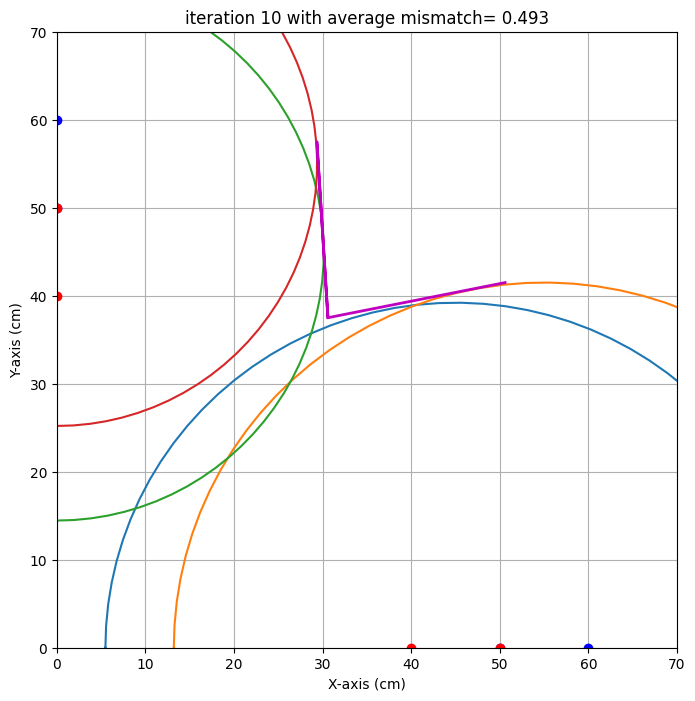

end iteration 10 with average mismatch= 0.493


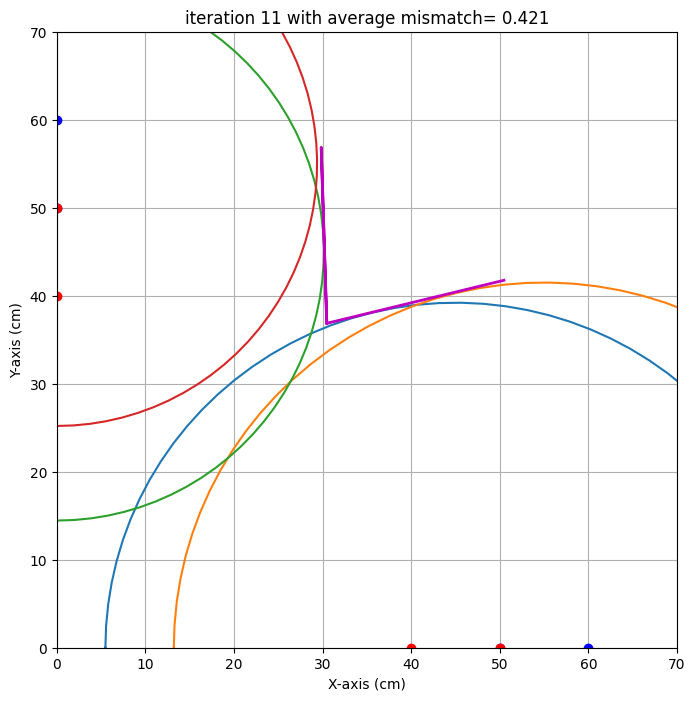

end iteration 11 with average mismatch= 0.421
end iteration 12 with average mismatch= 0.397
end iteration 13 with average mismatch= 0.392
end iteration 14 with average mismatch= 0.391
end iteration 15 with average mismatch= 0.391
end iteration 16 with average mismatch= 0.390
end iteration 17 with average mismatch= 0.390
end iteration 18 with average mismatch= 0.390
end iteration 19 with average mismatch= 0.380
end iteration 20 with average mismatch= 0.380
end iteration 21 with average mismatch= 0.380
end iteration 22 with average mismatch= 0.380
end iteration 23 with average mismatch= 0.380
end iteration 24 with average mismatch= 0.380
end iteration 25 with average mismatch= 0.380
end iteration 26 with average mismatch= 0.380
end iteration 27 with average mismatch= 0.380
end iteration 28 with average mismatch= 0.380
end iteration 29 with average mismatch= 0.380
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

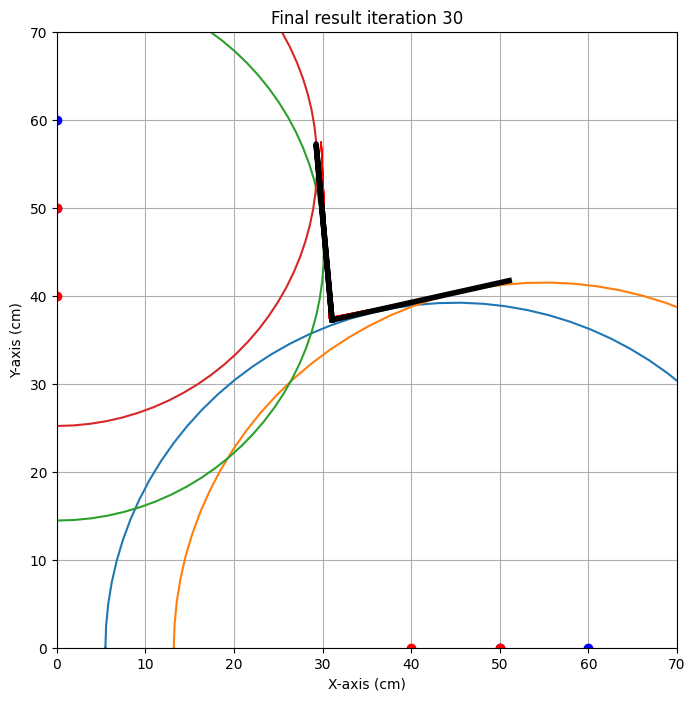

{'alpha': np.float64(12.604573182589768), 'alpha_eps': np.float64(1.3245135573522298), 'beta': np.float64(-5.147950986740209), 'beta_eps': np.float64(2.5454360250405728), 'x0': np.float64(31.062624391308287), 'x0_eps': np.float64(0.3166029403130324), 'y0': np.float64(37.238066655614624), 'y0_eps': np.float64(0.24503498505703902)}
Hugo
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  30   0  82.80
1  30   0  20   0  98.50
2   0  50   0  40  59.35
3   0  60   0  50  55.00


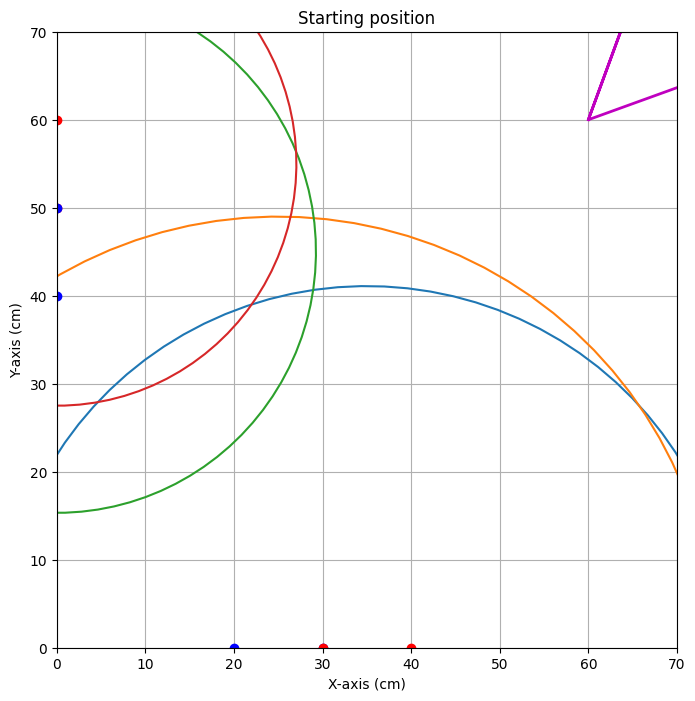


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.642


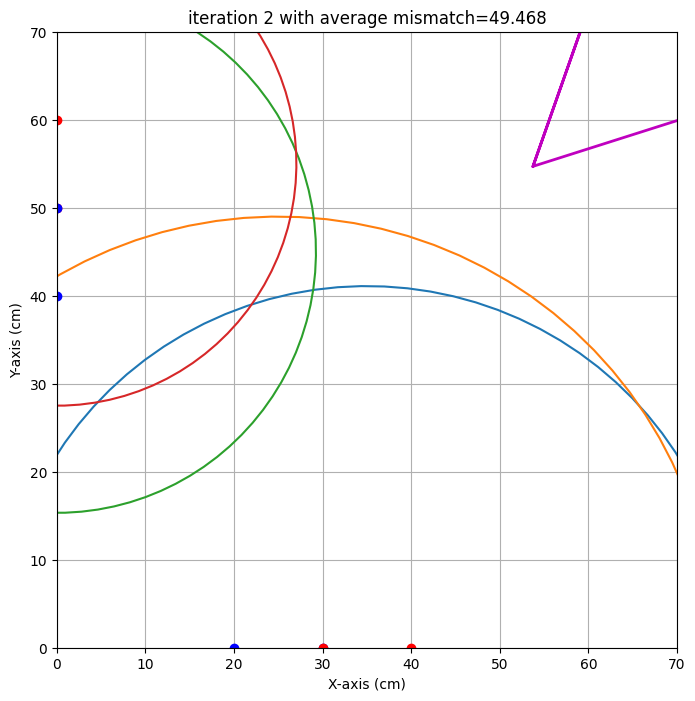

end iteration 2 with average mismatch=49.468


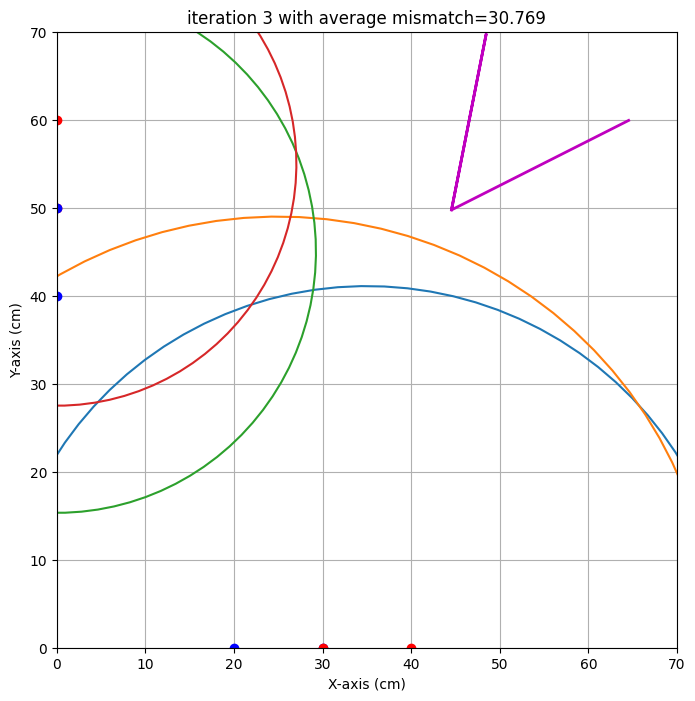

end iteration 3 with average mismatch=30.769


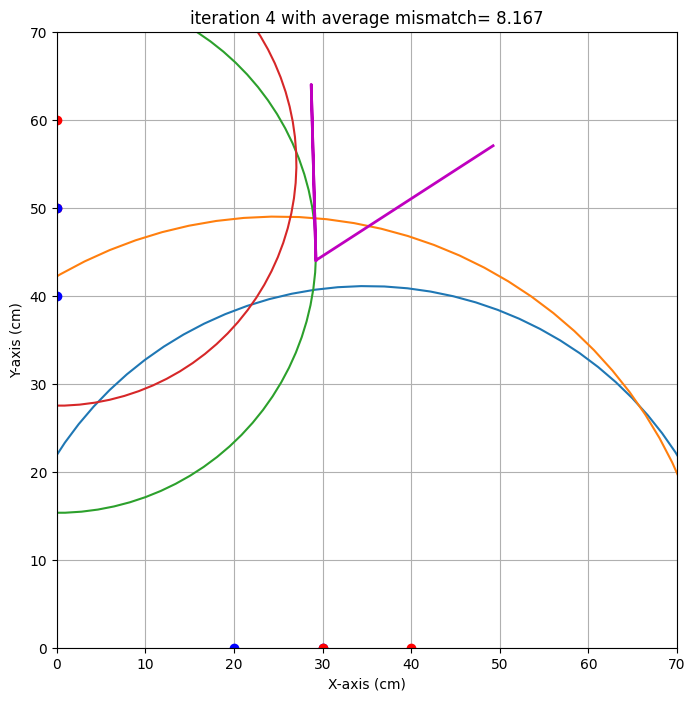

end iteration 4 with average mismatch= 8.167


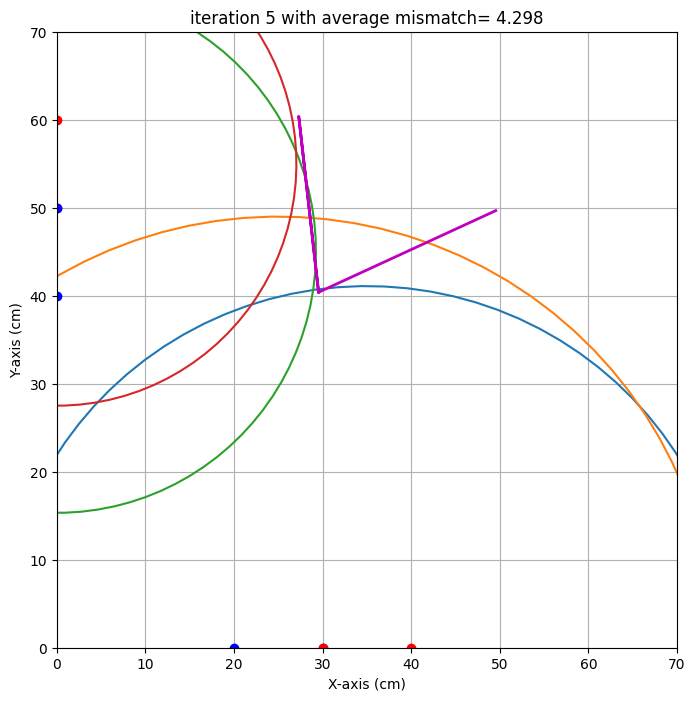

end iteration 5 with average mismatch= 4.298


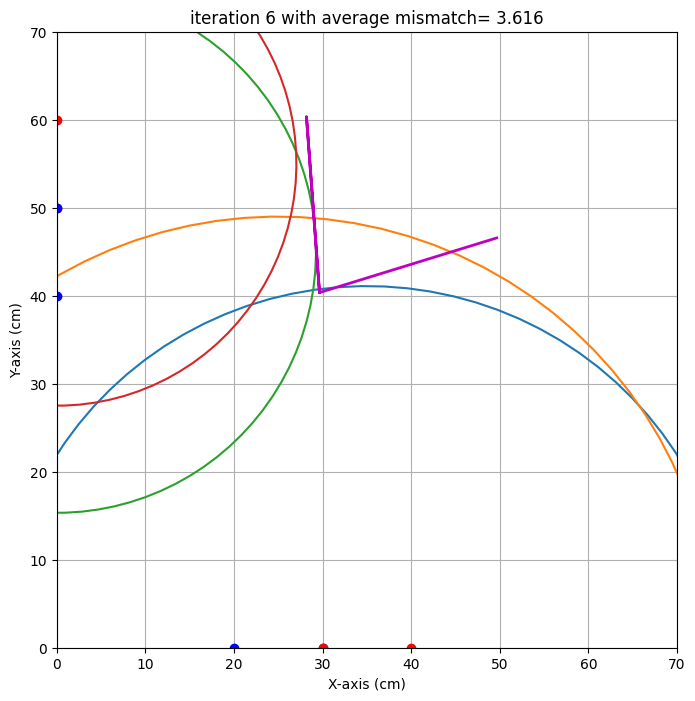

end iteration 6 with average mismatch= 3.616


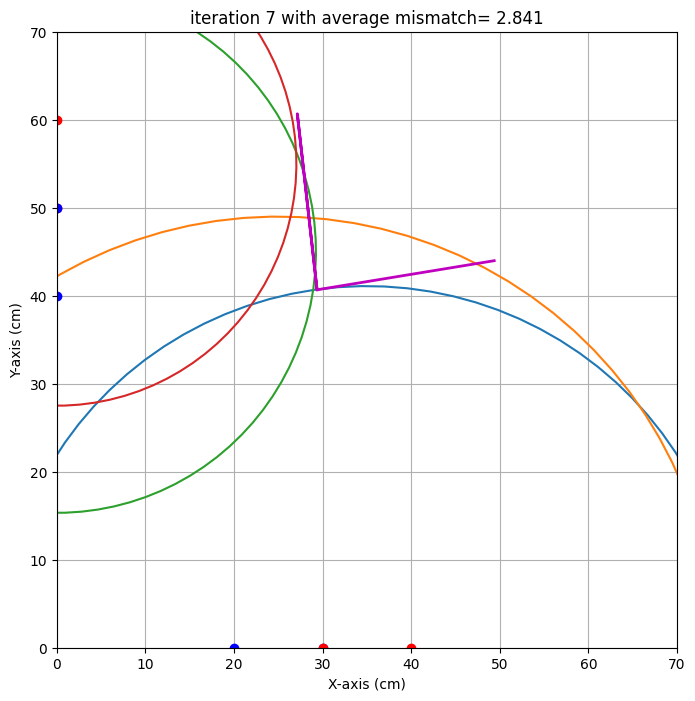

end iteration 7 with average mismatch= 2.841
end iteration 8 with average mismatch= 2.732
end iteration 9 with average mismatch= 2.631
end iteration 10 with average mismatch= 2.457


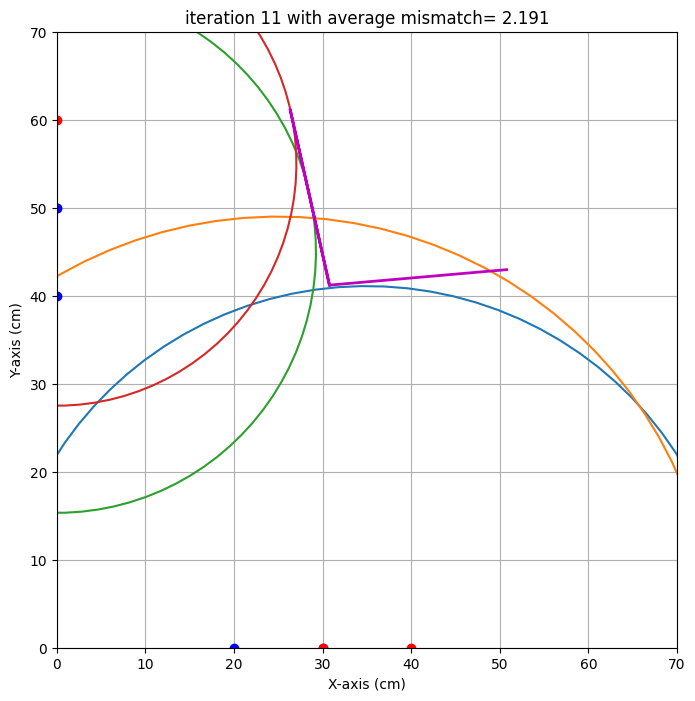

end iteration 11 with average mismatch= 2.191
end iteration 12 with average mismatch= 2.143
end iteration 13 with average mismatch= 2.143
end iteration 14 with average mismatch= 2.143
end iteration 15 with average mismatch= 2.143
end iteration 16 with average mismatch= 1.982
end iteration 17 with average mismatch= 1.923
end iteration 18 with average mismatch= 1.912
end iteration 19 with average mismatch= 1.912
end iteration 20 with average mismatch= 1.912
end iteration 21 with average mismatch= 1.912
end iteration 22 with average mismatch= 1.912
end iteration 23 with average mismatch= 1.912
end iteration 24 with average mismatch= 1.912
end iteration 25 with average mismatch= 1.912
end iteration 26 with average mismatch= 1.912
end iteration 27 with average mismatch= 1.912
end iteration 28 with average mismatch= 1.912
end iteration 29 with average mismatch= 1.912
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

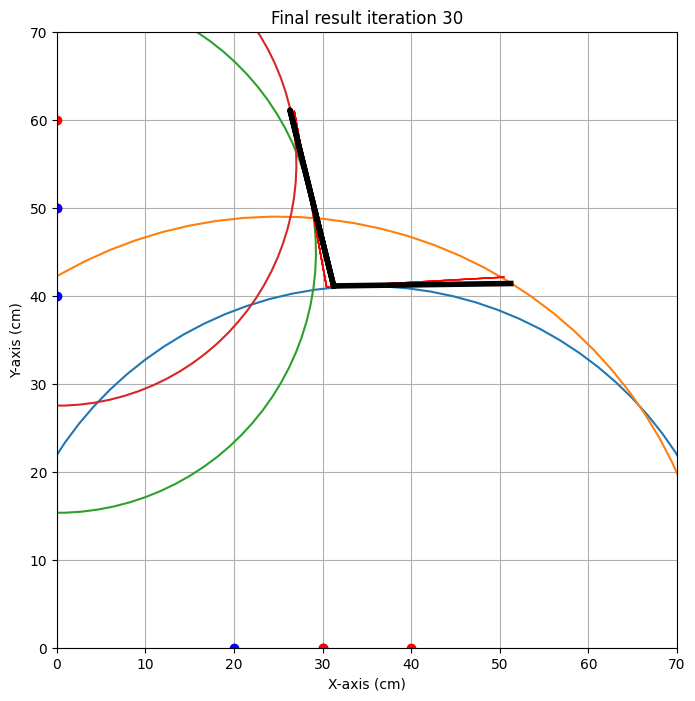

{'alpha': np.float64(0.7801648941877497), 'alpha_eps': np.float64(2.430081441044944), 'beta': np.float64(-13.844596475410444), 'beta_eps': np.float64(3.4874983719287407), 'x0': np.float64(31.24276757689843), 'x0_eps': np.float64(0.7918682597814382), 'y0': np.float64(41.11346445814284), 'y0_eps': np.float64(0.12524062795618818)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Teun 
x0 target is : 33.0. Gevonden waarde: 31.1 cm met een standaardafwijking van 0.3 cm 
y0 target is : 38.0. Gevonden waarde: 37.2 cm met een standaardafwijking van 0.2 cm 
alpha target is : 1.0. Gevonden waarde: 12.6 graden met een standaardafwijking van 1.3 graad 
beta target is : 1.0. Gevonden waarde: -5.1 graden met een standaardafwijking van 2.5 graad 

Hugo 
x0 target is : 33.0. Gevonden waarde: 31.2 cm met een standaardafwijking van 0.8 cm 
y0 target is : 38.0. Gevonden waarde: 41.1 cm met een standaardafwijking van 0.1 cm 
alpha target is : 1.0. Gevonden waarde: 0.8 graden met een standaardafwijking van 2.4 graad 
beta target is : 1.0. Gevonden waarde: -13.8 graden met een standaardafwijking van 3.5 graad 



## Opdracht 8: Iteratie1+ 15:00
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](schetsfinal.jpeg)


In [9]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [10]:
#Oude data
data11 ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,40,0,69.9],
    [45,0,60,0,72.35],
    [0,40,0,50,61.15],
    [0,45,0,60,62.27]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,50,0,91.2],
    [45,0,60,0,92.6],
    [0,40,0,50,61.10],
    [0,45,0,60,58.70]
    ])
      }

#[30,0,40,0,68],
 #   [35,0,45,0,65],
    #[0,48,0,58,69.28],
    #[0,53,0,63,70.48],    
  #  [0,58,0,68,73.64], 
    #[0,51,0,61,69.56],
    #[0,61,0,71,74.5],
   # [0,48,0,58,67.2]

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  40   0  72.7
1  40   0  50   0  78.0
2   0  48   0  58  55.7
3   0  58   0  68  59.7
4  50   0  60   0  80.7


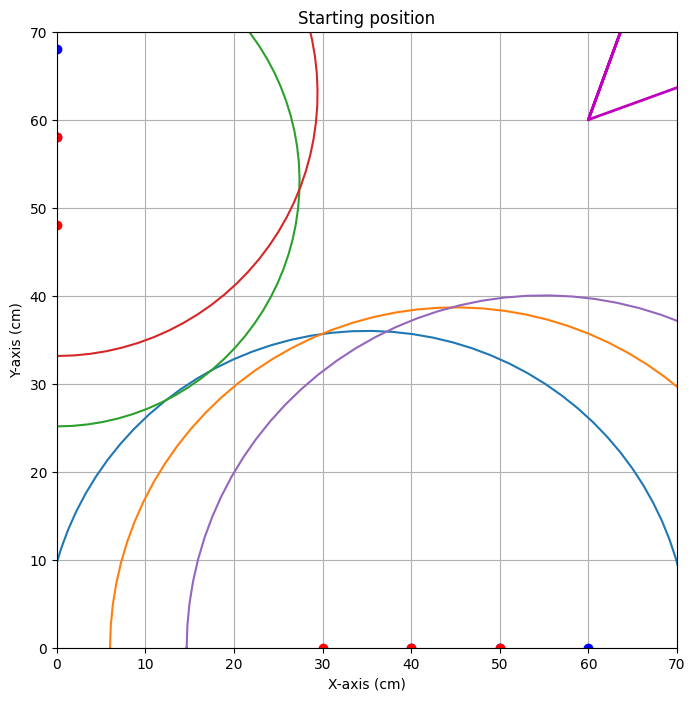


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.275


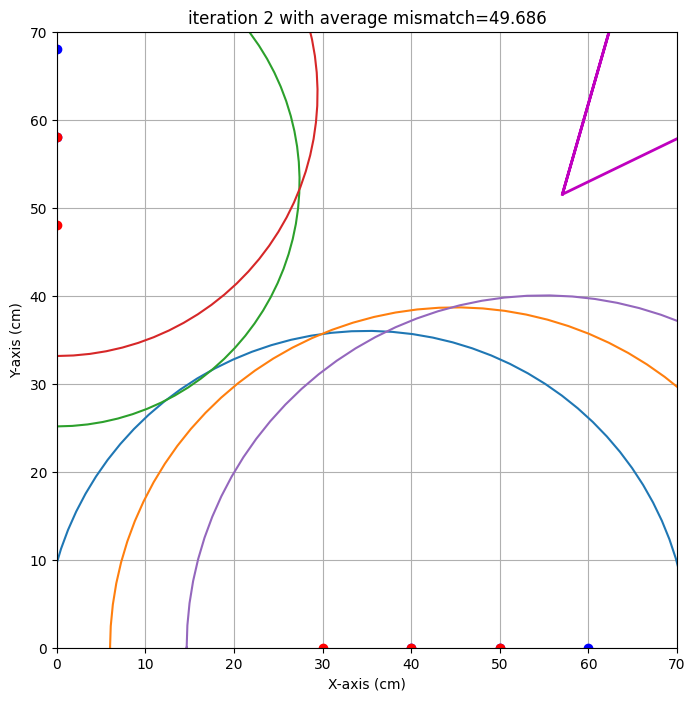

end iteration 2 with average mismatch=49.686


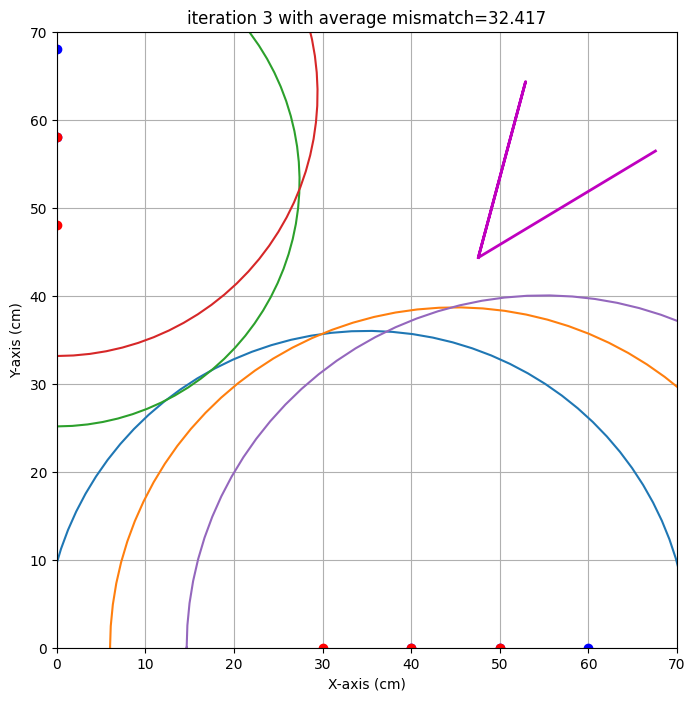

end iteration 3 with average mismatch=32.417


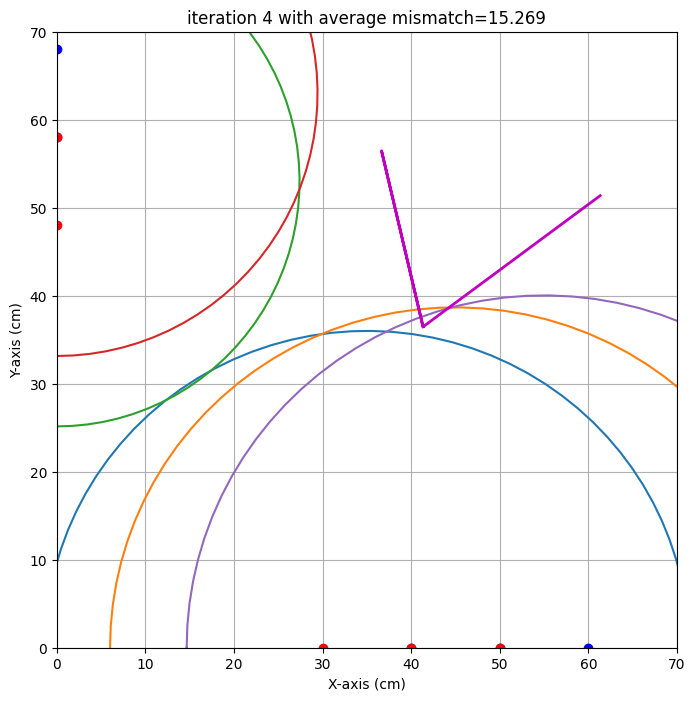

end iteration 4 with average mismatch=15.269


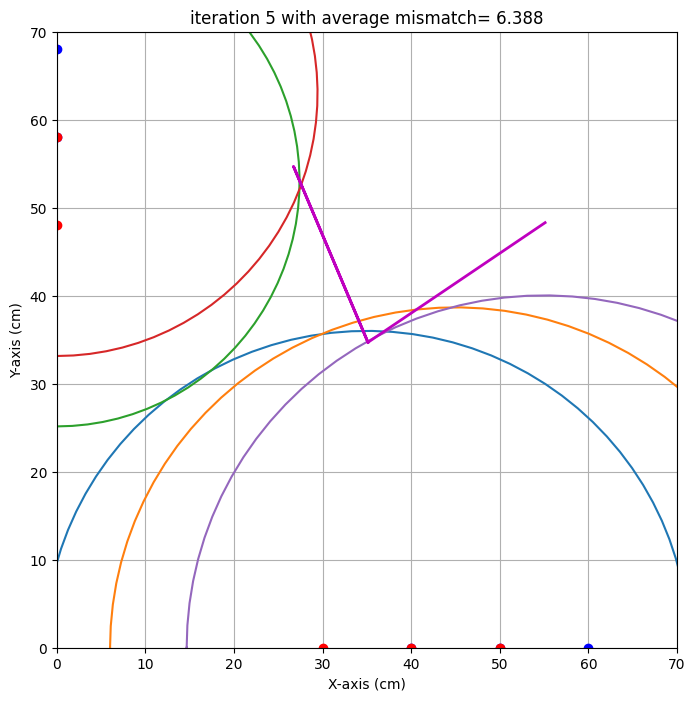

end iteration 5 with average mismatch= 6.388


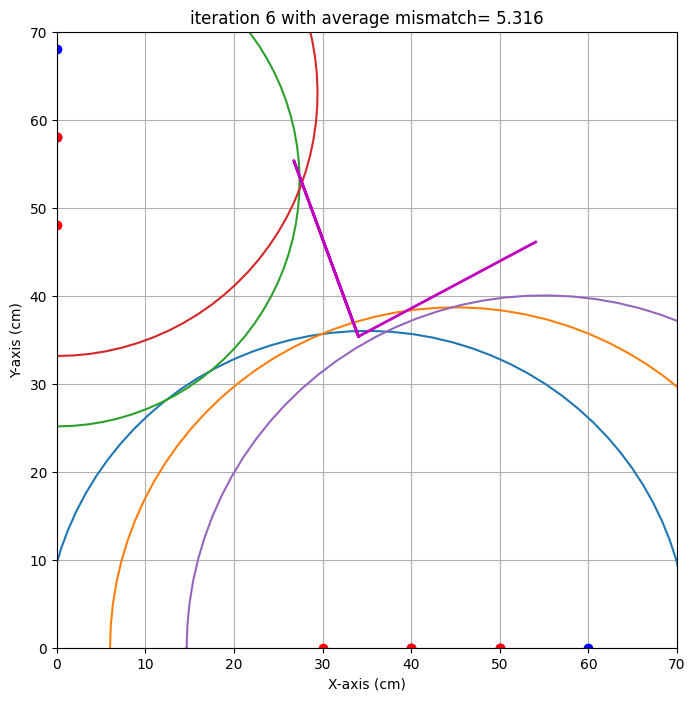

end iteration 6 with average mismatch= 5.316


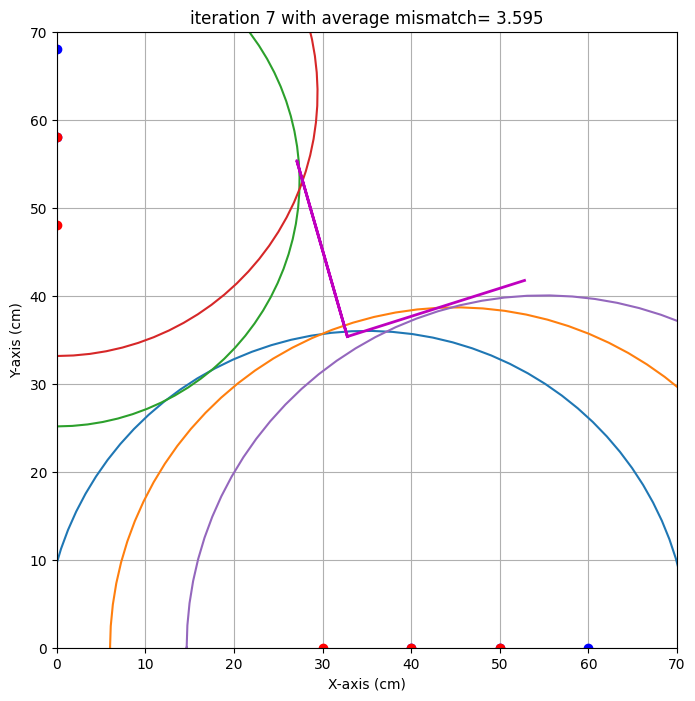

end iteration 7 with average mismatch= 3.595


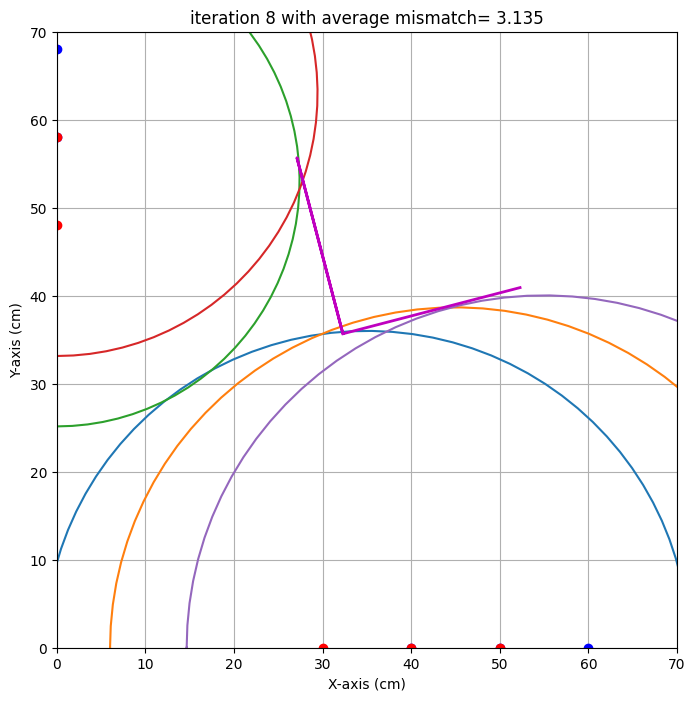

end iteration 8 with average mismatch= 3.135


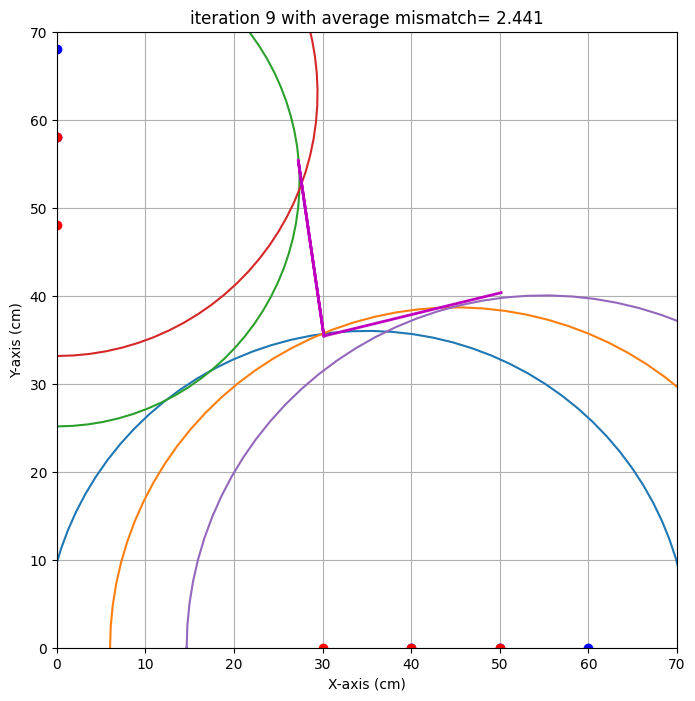

end iteration 9 with average mismatch= 2.441
end iteration 10 with average mismatch= 2.441
end iteration 11 with average mismatch= 2.441


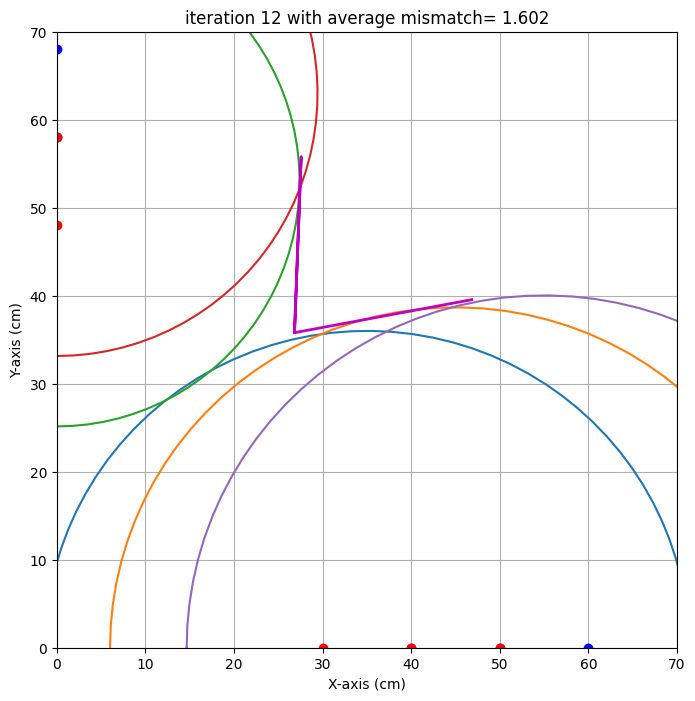

end iteration 12 with average mismatch= 1.602


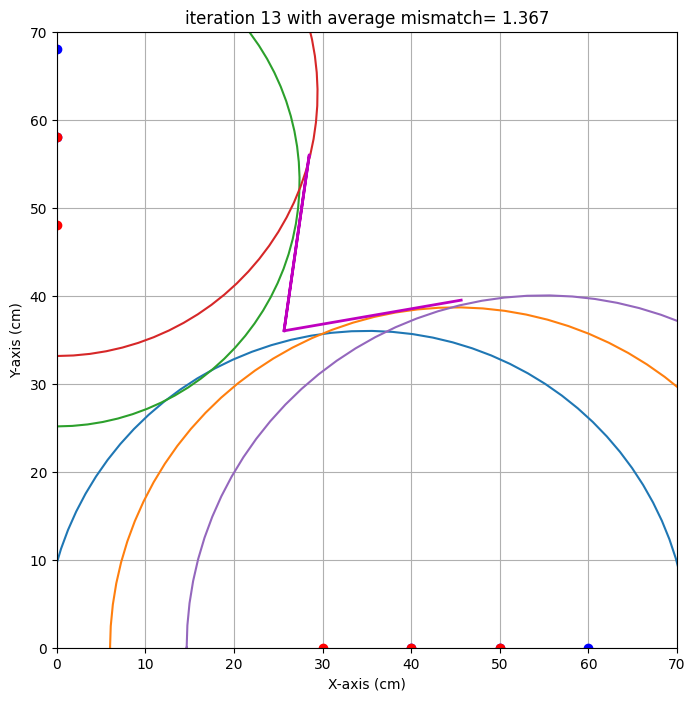

end iteration 13 with average mismatch= 1.367


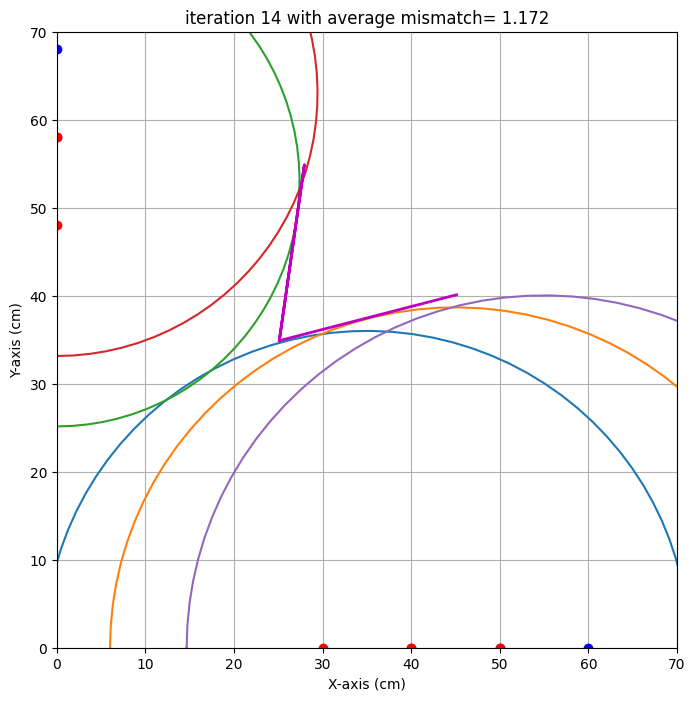

end iteration 14 with average mismatch= 1.172
end iteration 15 with average mismatch= 1.154
end iteration 16 with average mismatch= 1.133
end iteration 17 with average mismatch= 1.130
end iteration 18 with average mismatch= 1.117
end iteration 19 with average mismatch= 1.053
end iteration 20 with average mismatch= 1.053
end iteration 21 with average mismatch= 1.010
end iteration 22 with average mismatch= 1.003
end iteration 23 with average mismatch= 1.002
end iteration 24 with average mismatch= 1.002
end iteration 25 with average mismatch= 1.002
end iteration 26 with average mismatch= 1.002
end iteration 27 with average mismatch= 1.002
end iteration 28 with average mismatch= 1.002
end iteration 29 with average mismatch= 1.002
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.002
###############################################################################
end of iteration  30
Best alp

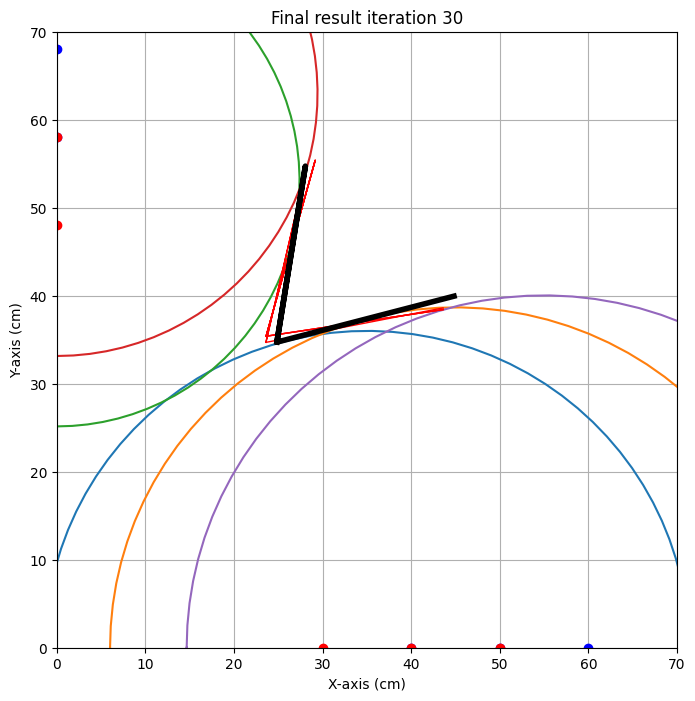

{'alpha': np.float64(14.633151488233253), 'alpha_eps': np.float64(6.006628743961798), 'beta': np.float64(9.141539199885953), 'beta_eps': np.float64(6.355024504400729), 'x0': np.float64(24.834752693430314), 'x0_eps': np.float64(1.2365253449109517), 'y0': np.float64(34.72652682062955), 'y0_eps': np.float64(0.6711464541008496)}
locatie 2
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


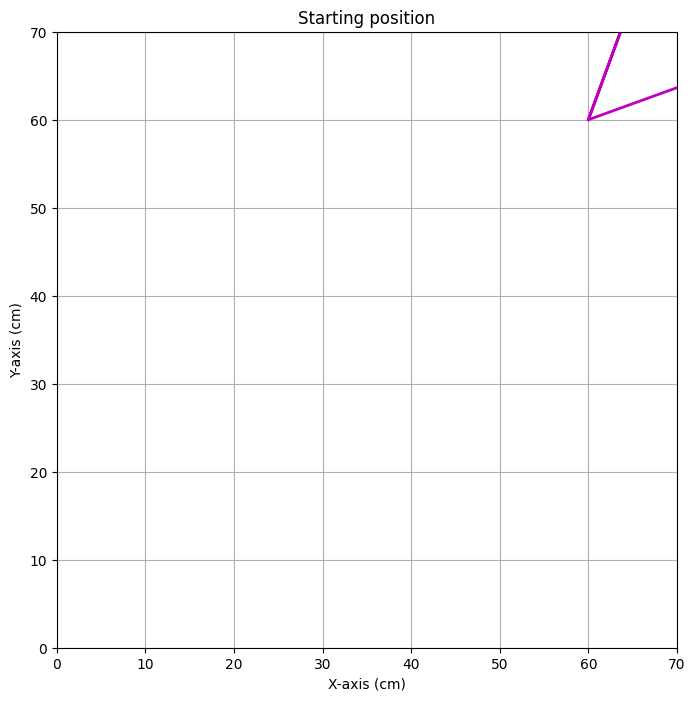


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan


c:\Users\ninam\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ninam\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with average mismatch=   nan
end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatc

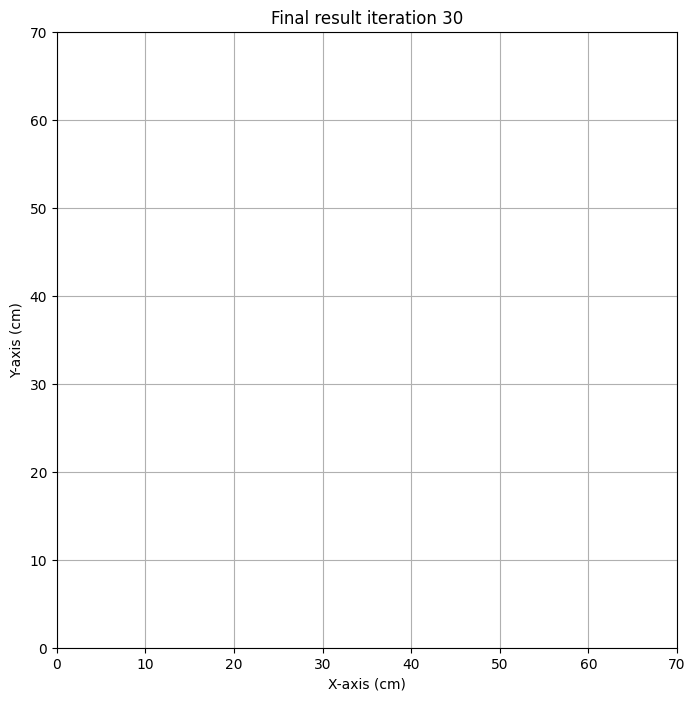

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}
locatie 1 
x0 target is : 27.7. Gevonden waarde: 24.8 cm met een standaardafwijking van 1.2 cm 
y0 target is : 33.0. Gevonden waarde: 34.7 cm met een standaardafwijking van 0.7 cm 
alpha target is : 14.0. Gevonden waarde: 14.6 graden met een standaardafwijking van 6.0 graad 
beta target is : 4.0. Gevonden waarde: 9.1 graden met een standaardafwijking van 6.4 graad 

locatie 2 
x0 target is : 31.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 45.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 1.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : 1.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27.7 ,
           'y0': 33,
           'alpha': 14,
           'beta' : 4
          },
           'locatie 2':{'x0': 31,
           'y0': 45,
           'alpha': 1,
           'beta' : 1
          }
            }

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [30,0,40,0,72.70],
    [40,0,50,0,78.0],
    [0,48,0,58,55.70],
    [0,58,0,68,59.7],
    [50,0,60,0,80.7]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  35   0  50   0  49.70
1  40   0  60   0  52.70
2   0  35   0  50  82.80
3   0  45   0  65  89.26


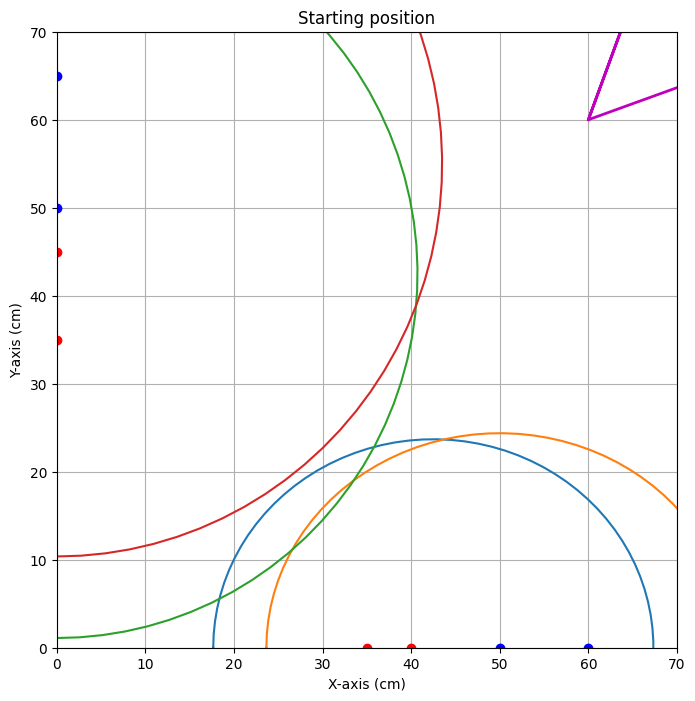


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.788


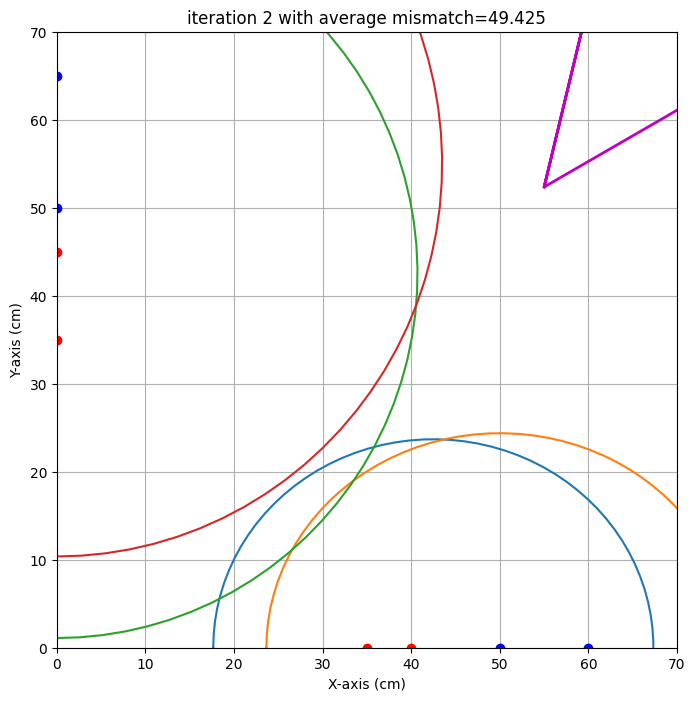

end iteration 2 with average mismatch=49.425


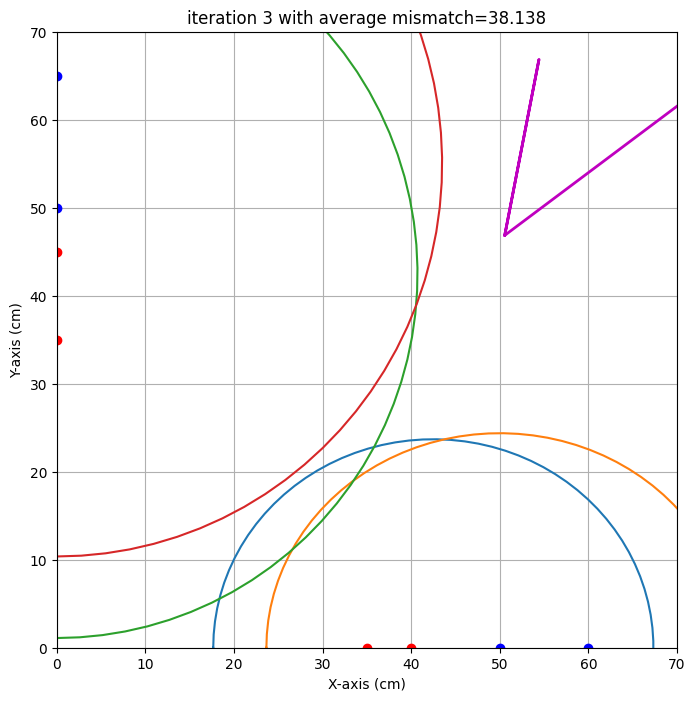

end iteration 3 with average mismatch=38.138


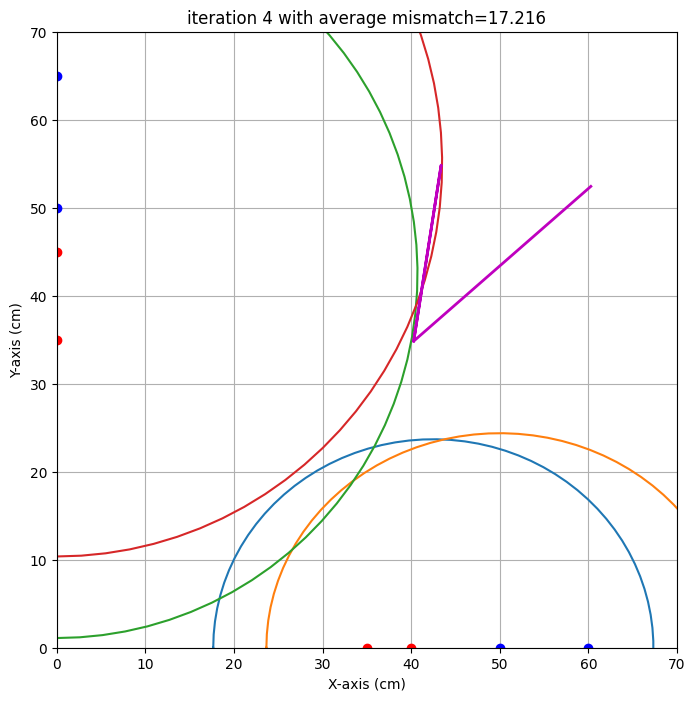

end iteration 4 with average mismatch=17.216


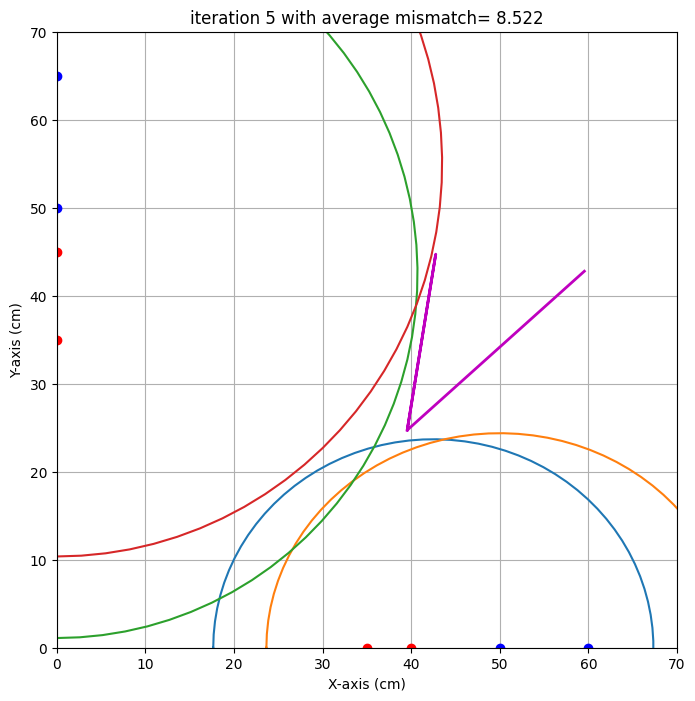

end iteration 5 with average mismatch= 8.522


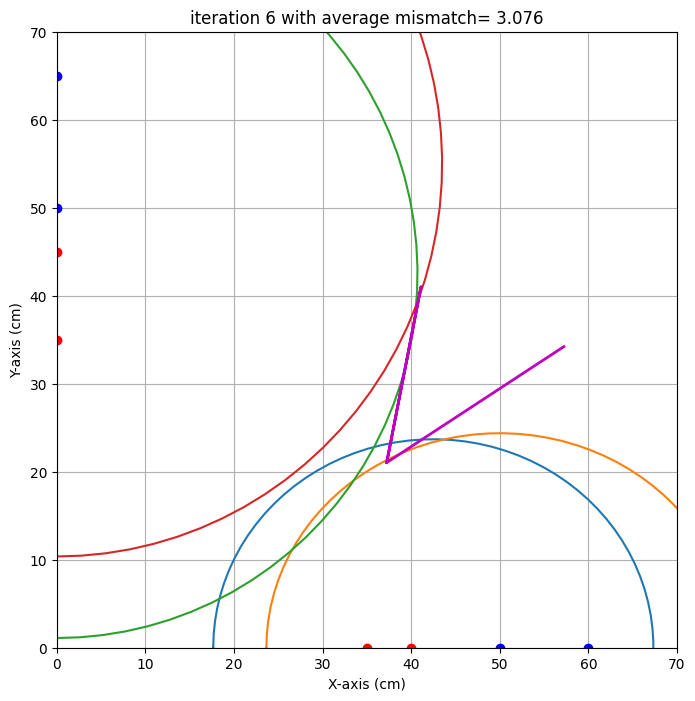

end iteration 6 with average mismatch= 3.076
end iteration 7 with average mismatch= 2.834
end iteration 8 with average mismatch= 2.815
end iteration 9 with average mismatch= 2.814
end iteration 10 with average mismatch= 2.557


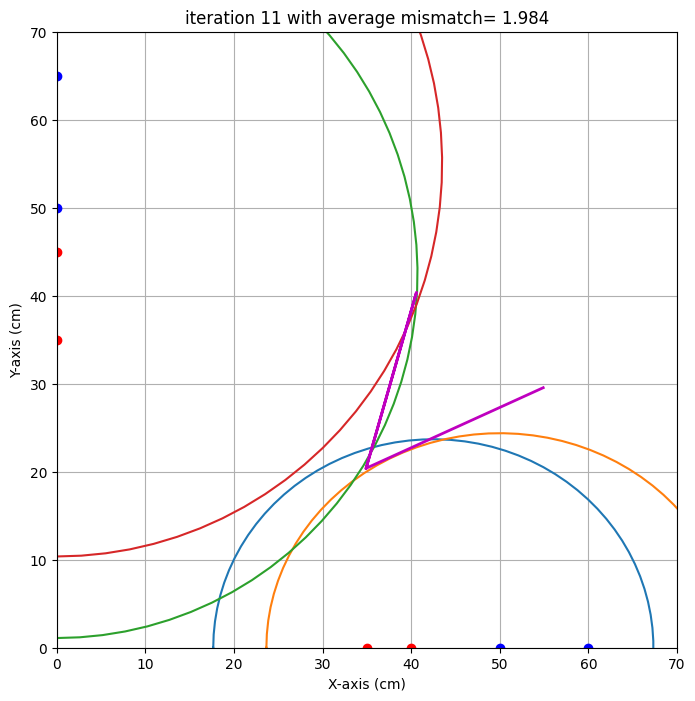

end iteration 11 with average mismatch= 1.984


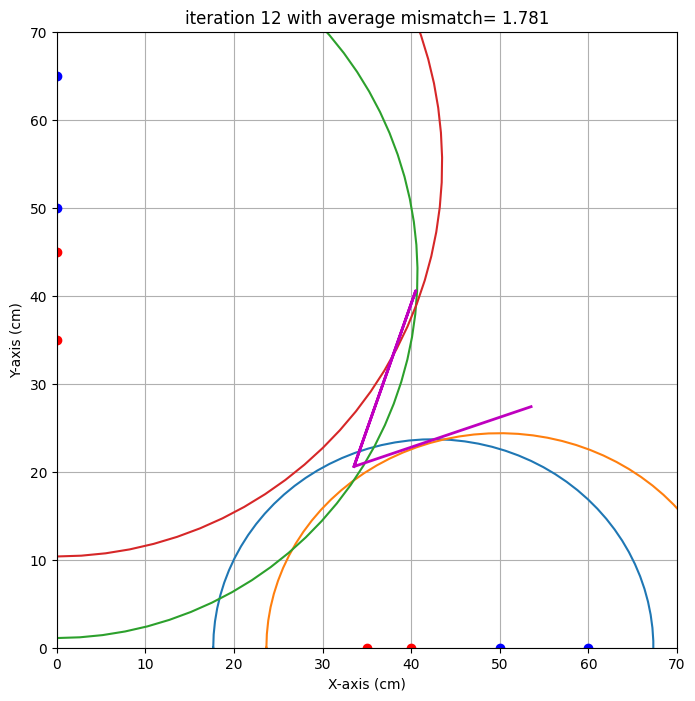

end iteration 12 with average mismatch= 1.781


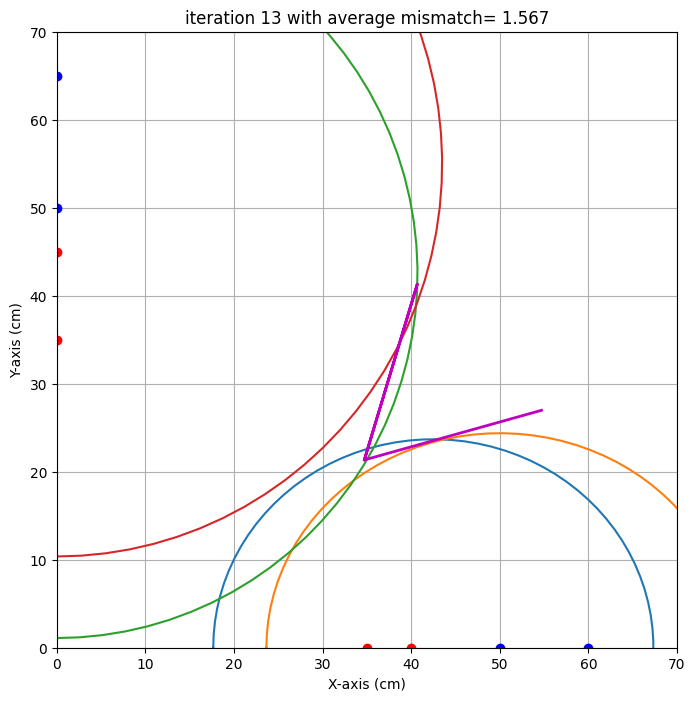

end iteration 13 with average mismatch= 1.567


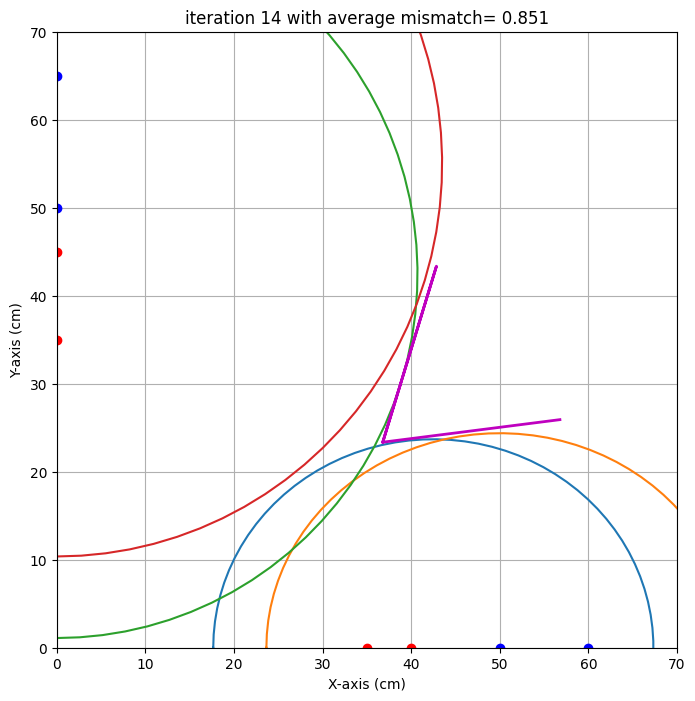

end iteration 14 with average mismatch= 0.851


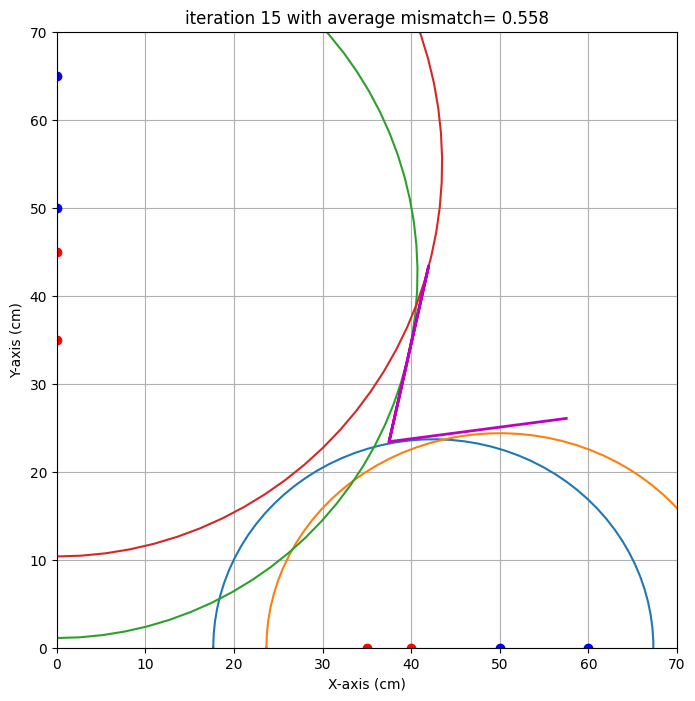

end iteration 15 with average mismatch= 0.558
end iteration 16 with average mismatch= 0.541
end iteration 17 with average mismatch= 0.535
end iteration 18 with average mismatch= 0.535
end iteration 19 with average mismatch= 0.498
end iteration 20 with average mismatch= 0.498
end iteration 21 with average mismatch= 0.498
end iteration 22 with average mismatch= 0.498
end iteration 23 with average mismatch= 0.498
end iteration 24 with average mismatch= 0.498
end iteration 25 with average mismatch= 0.498
end iteration 26 with average mismatch= 0.498
end iteration 27 with average mismatch= 0.498
end iteration 28 with average mismatch= 0.498
end iteration 29 with average mismatch= 0.498
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.498
###############################################################################
end of iteration  30
Best alpha=   4.71 with uncertainty=   2.48
Best beta 

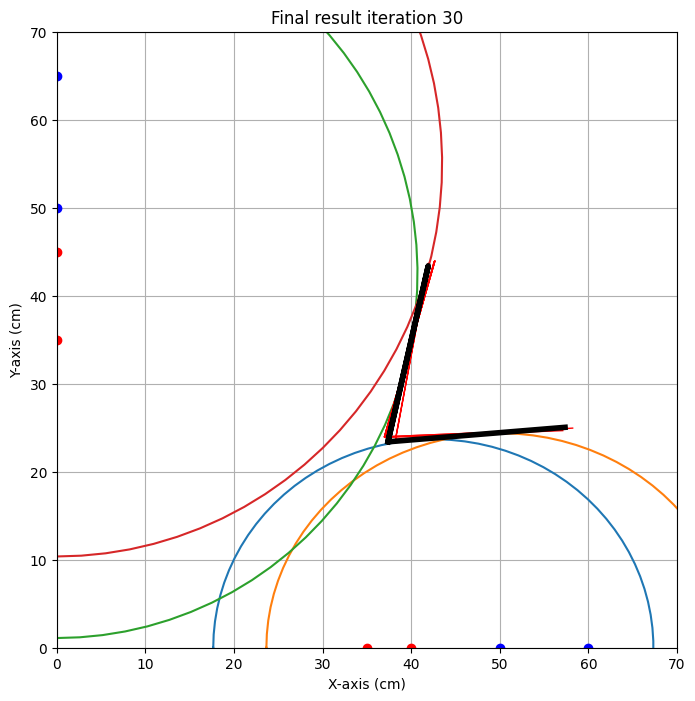

{'alpha': np.float64(4.712138346284368), 'alpha_eps': np.float64(2.476385313322278), 'beta': np.float64(12.823686888429448), 'beta_eps': np.float64(3.0780882413174986), 'x0': np.float64(37.37379566292638), 'x0_eps': np.float64(0.8570291942427914), 'y0': np.float64(23.397442778223905), 'y0_eps': np.float64(0.5735516176759816)}
test locatie 
x0 target is : 37.7. Gevonden waarde: 37.4 cm met een standaardafwijking van 0.9 cm 
y0 target is : 22.2. Gevonden waarde: 23.4 cm met een standaardafwijking van 0.6 cm 
alpha target is : 7.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 2.5 graad 
beta target is : 14.0. Gevonden waarde: 12.8 graden met een standaardafwijking van 3.1 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 37.7 ,
                    'y0': 22.2 ,
                    'alpha' : 7 ,
                    'beta' : 14 ,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [35,0,50,0,49.7],
                    [40,0,60,0,52.7],
                    [0,35,0,50,82.8],
                    [0,45,0,65,89.26]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](schets1.jpeg "Versie 1 algoritme")

Figuur: ![Alt](schetsfinal.jpeg "Laatste versie algoritme")



Gemaakte evaluatie:
Ging niet goed met scherpe hoeken
Beslissingen/verandering
Afstand tussen sensoren vergroot


In [13]:
#Resulaat
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

test locatie 
x0 target is : 37.7. Gevonden waarde: 37.4 cm met een standaardafwijking van 0.9 cm 
y0 target is : 22.2. Gevonden waarde: 23.4 cm met een standaardafwijking van 0.6 cm 
alpha target is : 7.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 2.5 graad 
beta target is : 14.0. Gevonden waarde: 12.8 graden met een standaardafwijking van 3.1 graad 

